# DATA SCIENTIST SALARY ANALYSIS & PREDICTION ACROSS CONTINENTS 

### DATA CLEANING & INTERROGATION

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import janitor
from plotnine import *

In [2]:
ds_data = pd.read_csv('salaries.csv')

In [3]:
ds_data.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EN,FT,Data Analist,65664,EUR,69120,NL,0,NL,M
1,2025,EN,FT,Data Analist,47652,EUR,50160,NL,0,NL,M
2,2025,EN,FT,Data Engineer,158113,USD,158113,US,0,US,M
3,2025,EN,FT,Data Engineer,87795,USD,87795,US,0,US,M
4,2025,EX,FT,Data Engineer,351410,USD,351410,US,0,US,M


In [4]:
ds_data.isna().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [5]:
ds_data.duplicated().sum()

np.int64(52997)

In [6]:
ds_data2 = ds_data.drop_duplicates()

In [7]:
ds_data3 = ds_data2[ds_data2['job_title'].str.contains('Data Scientist', na = False)]

In [8]:
ds_data3.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
38,2025,MI,FT,Data Scientist,209100,USD,209100,US,0,US,M
39,2025,MI,FT,Data Scientist,154500,USD,154500,US,0,US,M
40,2025,SE,FT,Data Scientist,335720,USD,335720,US,100,US,M
41,2025,SE,FT,Data Scientist,163064,USD,163064,US,100,US,M
42,2025,EN,FT,Data Scientist,77000,USD,77000,US,0,US,M


In [9]:
ds_data3.shape

(5873, 11)

In [10]:
ds_data3.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,5873.000000,5.873000e+03,5873.000000,5873.000000
mean,2023.946024,1.763676e+05,152618.111187,27.396561
std,0.900905,5.058921e+05,72023.954953,44.142398
min,2020.000000,1.500000e+04,15281.000000,0.000000
25%,2024.000000,1.013000e+05,101000.000000,0.000000
50%,2024.000000,1.440000e+05,143060.000000,0.000000
75%,2025.000000,1.956000e+05,193000.000000,100.000000
max,2025.000000,3.040000e+07,750000.000000,100.000000


In [11]:
ds_data3.duplicated().sum()

np.int64(0)

In [12]:
ds_data3.select_dtypes(include = 'number').skew()

work_year        -1.097433
salary           41.326106
salary_in_usd     1.433778
remote_ratio      1.013719
dtype: float64

In [13]:
ds_data3.count()

work_year             5873
experience_level      5873
employment_type       5873
job_title             5873
salary                5873
salary_currency       5873
salary_in_usd         5873
employee_residence    5873
remote_ratio          5873
company_location      5873
company_size          5873
dtype: int64

In [14]:
ds_data3['experience_level'].unique()

<ArrowStringArray>
['MI', 'SE', 'EN', 'EX']
Length: 4, dtype: str

In [15]:
ds_data3['employment_type'].unique()

<ArrowStringArray>
['FT', 'PT', 'CT', 'FL']
Length: 4, dtype: str

In [16]:
ds_data3['salary_currency'].unique()

<ArrowStringArray>
['USD', 'GBP', 'EUR', 'CAD', 'HUF', 'TWD', 'BRL', 'CHF', 'AUD', 'INR', 'PLN',
 'NOK', 'HKD', 'THB', 'TRY', 'CLP', 'SGD']
Length: 17, dtype: str

In [17]:
ds_data3['employee_residence'].unique()

<ArrowStringArray>
['US', 'GB', 'NL', 'LT', 'AT', 'CA', 'FR', 'SG', 'IN', 'AU', 'IE', 'BG', 'SK',
 'NZ', 'ES', 'LV', 'BR', 'HU', 'CH', 'TW', 'BE', 'DE', 'IT', 'KR', 'EG', 'JP',
 'MX', 'FI', 'AR', 'CL', 'PL', 'PT', 'KE', 'ZA', 'EE', 'UA', 'RO', 'PK', 'GR',
 'TR', 'PH', 'RU', 'AD', 'EC', 'NO', 'UZ', 'HK', 'TH', 'CY', 'DO', 'DZ', 'NG',
 'AE', 'RS']
Length: 54, dtype: str

### EXPLORATORY DATA ANALYSIS

1. GEOGRAPHICAL & DISTRIBUTIONAL QUESTIONS


In [18]:
# What is the median & mean annual salary for data-scientists within each of the continents?

# Define continent mapping for all country codes in my data
continent_map = {
    # Europe
    'NL': 'Europe', 'GB': 'Europe', 'CH': 'Europe', 'LT': 'Europe', 'SK': 'Europe',
    'AT': 'Europe', 'LV': 'Europe', 'FR': 'Europe', 'IE': 'Europe', 'DE': 'Europe',
    'ES': 'Europe', 'DK': 'Europe', 'PT': 'Europe', 'FI': 'Europe', 'BG': 'Europe',
    'PL': 'Europe', 'BE': 'Europe', 'IT': 'Europe', 'RS': 'Europe', 'UA': 'Europe',
    'CY': 'Europe', 'SE': 'Europe', 'HU': 'Europe', 'NO': 'Europe', 'MT': 'Europe',
    'XK': 'Europe', 'LU': 'Europe', 'CZ': 'Europe', 'GR': 'Europe', 'HR': 'Europe',
    'TR': 'Europe', 'RO': 'Europe', 'GE': 'Europe', 'BA': 'Europe', 'EE': 'Europe',
    'SI': 'Europe', 'RU': 'Europe', 'AD': 'Europe', 'MD': 'Europe', 'JE': 'Europe',

    # Americas
    'US': 'Americas', 'CA': 'Americas', 'AR': 'Americas', 'MX': 'Americas',
    'BR': 'Americas', 'PR': 'Americas', 'PE': 'Americas', 'SV': 'Americas',
    'EC': 'Americas', 'CL': 'Americas', 'DO': 'Americas', 'CO': 'Americas',
    'CR': 'Americas', 'JM': 'Americas', 'BM': 'Americas', 'VE': 'Americas',
    'BO': 'Americas', 'HN': 'Americas', 

    # Asia
    'IN': 'Asia', 'SG': 'Asia', 'TW': 'Asia', 'ID': 'Asia', 'JO': 'Asia',
    'PH': 'Asia', 'HK': 'Asia', 'JP': 'Asia', 'MY': 'Asia', 'KR': 'Asia',
    'IL': 'Asia', 'LB': 'Asia', 'PK': 'Asia', 'VN': 'Asia', 'SA': 'Asia',
    'OM': 'Asia', 'TH': 'Asia', 'QA': 'Asia', 'AE': 'Asia', 'CN': 'Asia',
    'IQ': 'Asia', 'KW': 'Asia', 'IR': 'Asia', 'UZ': 'Asia', 'AM': 'Asia',

    # Africa
    'ZA': 'Africa', 'ZM': 'Africa', 'RW': 'Africa', 'EG': 'Africa', 'NG': 'Africa',
    'KE': 'Africa', 'UG': 'Africa', 'MU': 'Africa', 'TN': 'Africa', 'GH': 'Africa',
    'CF': 'Africa', 'DZ': 'Africa',

    # Oceania
    'AU': 'Oceania', 'NZ': 'Oceania', 'AS': 'Oceania',
}


In [19]:
# Map countries to continents

ds_data3['continent'] = ds_data2['employee_residence'].map(continent_map)

In [20]:
ds_data3.tail()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,continent
105425,2021,MI,FT,Data Scientist,160000,SGD,119059,SG,100,IL,M,Asia
105429,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L,Americas
105430,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L,Americas
105431,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S,Americas
105433,2021,SE,FT,Data Scientist,7000000,INR,94665,IN,50,IN,L,Asia


In [21]:
# Check for unmapped countries

unmapped = ds_data3[ds_data3['continent'].isna()]['employee_residence'].unique()
print('Unmapped countries :', unmapped)

Unmapped countries : <ArrowStringArray>
[]
Length: 0, dtype: str


In [22]:
# Actual mean & median salary calculation

continent_stats = (ds_data3.groupby('continent')['salary_in_usd']
                  .agg(mean_salary ='mean',
                       median_salary ='median',
                       count ='count')
                  .round(2)
                  .sort_values('mean_salary', ascending=False))

print(continent_stats)

           mean_salary  median_salary  count
continent                                   
Americas     161136.12       151000.0   5227
Africa       114053.81        93300.0     21
Oceania      113133.77       110000.0     43
Europe        82736.51        68706.0    529
Asia          57361.72        40481.0     53


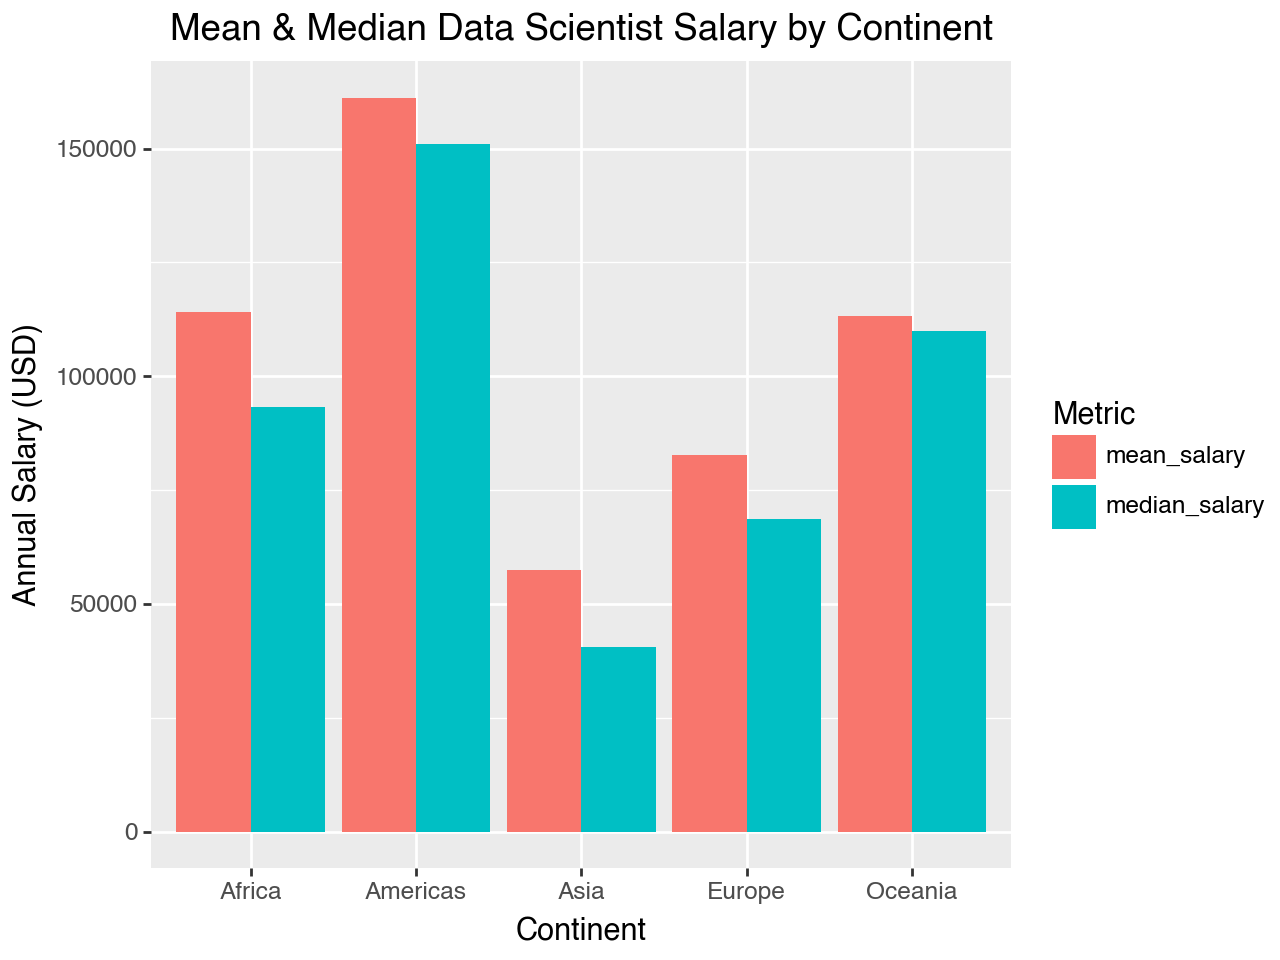

In [23]:
# Mean & Median Visuals

# Start by making the data long

continent_long = continent_stats.reset_index().melt(
    id_vars='continent',
    value_vars=['mean_salary', 'median_salary'],
    var_name='metric',
    value_name='salary'
)

# Actual plot
(
    ggplot(continent_long, aes(x='continent',y='salary', fill='metric'))
    +geom_col(position ='dodge')
    +theme()
    +labs(title='Mean & Median Data Scientist Salary by Continent',
        x='Continent',
        y='Annual Salary (USD)',
        fill='Metric')
)

##### Interpretation
Data scientist salaries are right-skewed across all continents, with Americas commanding the highest compensation. The median is the preferred central tendency measure here as outliers inflate the mean in every region.

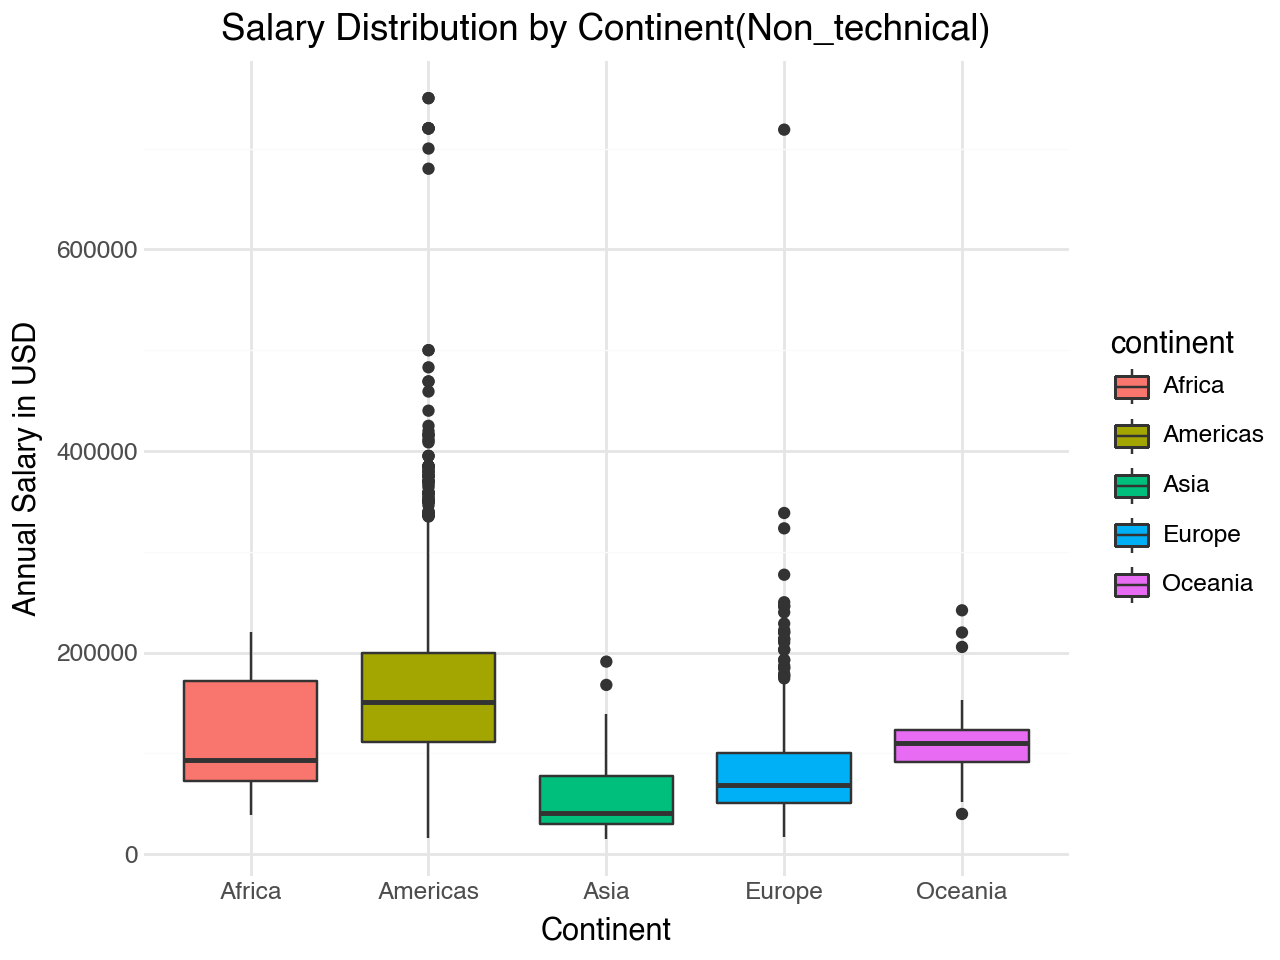

In [24]:
# How does the salary variance(spread) differ between continents?
# Does north america show a wider distribution of salaries compared to africa or asia?
# Are there extreme outliers in specific regions that pull the global average away from the typical salary?

(
    ggplot(ds_data3, aes(x='continent', y='salary_in_usd', fill='continent'))
            +geom_boxplot()
            +theme_minimal()
            +labs(title='Salary Distribution by Continent(Non_technical)',
                 x ='Continent',
                 y='Annual Salary in USD')
)

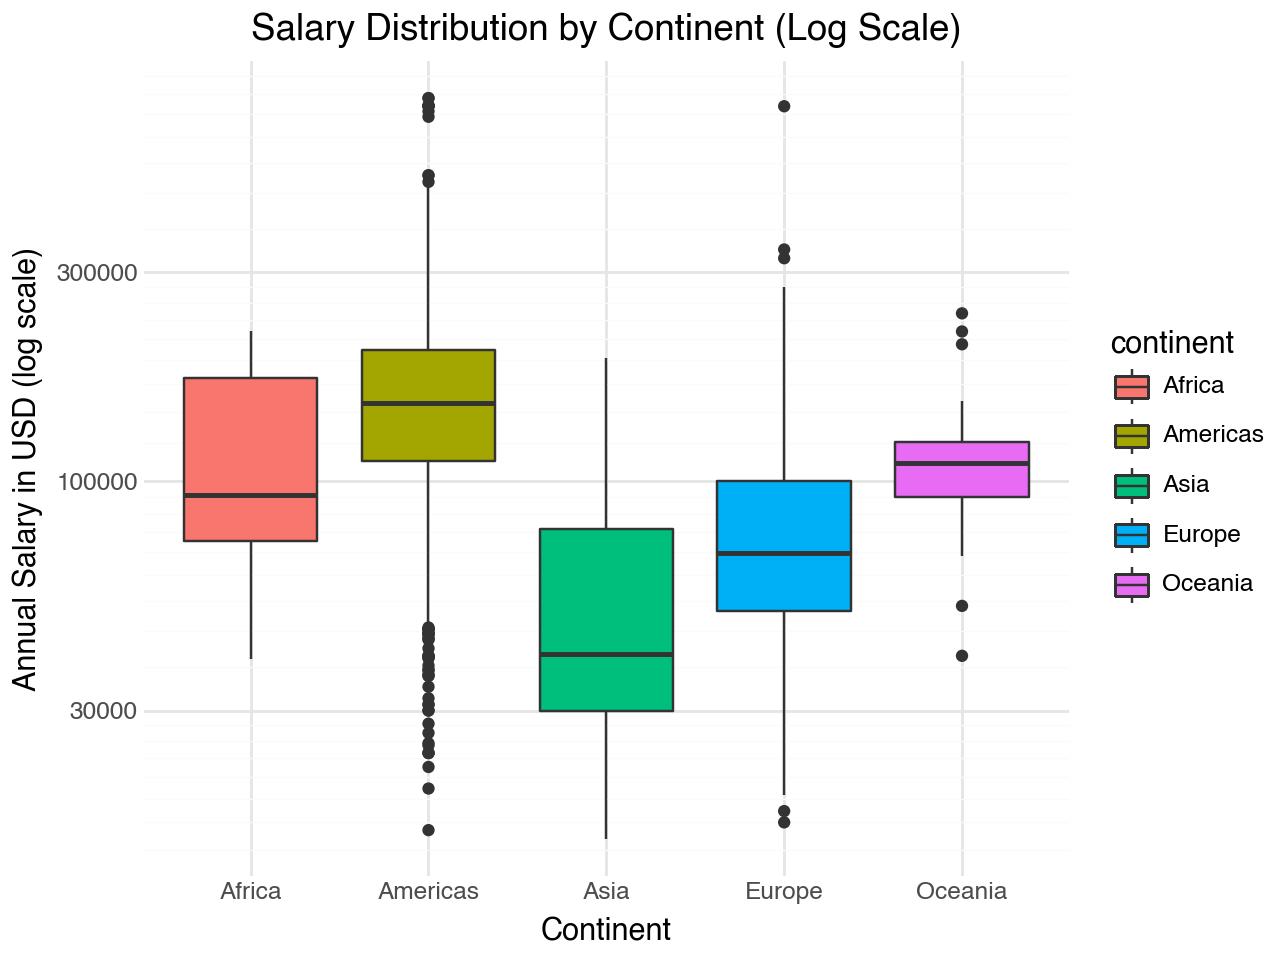

In [25]:
from plotnine import scale_y_log10

(
    ggplot(ds_data3, aes(x='continent', y='salary_in_usd', fill='continent'))
    + geom_boxplot()
    + scale_y_log10()
    + theme_minimal()
    + labs(title='Salary Distribution by Continent (Log Scale)',
           x='Continent', y='Annual Salary in USD (log scale)')
)

##### How does the salary variance(spread) differ between continents? 
-Americas:tallest box (approx $100k–$200k range), highest variance, most salary spread

-Europe:similar box height to Americas but sitting lower, also wide spread

-Asia:surprisingly tall box but stretching downward (approx $30k–$80k), wide spread on the lower end

-Oceania:medium box, fairly consistent salaries

-Africa:shortest box, most consistent/tightly clustered salaries despite being low-paid

##### Does north america show a wider distribution of salaries compared to africa or asia?

Americas is wider at the top end — its box sits higher and stretches further up

Asia is actually comparable in box height but spread across lower values

Africa has the least spread of all, short box, short whiskers, very few outliers

##### Are there extreme outliers in specific regions that pull the global average away from the typical salary?

Yes, Americas and Europe are the main culprits:

Americas has a long upper whisker stretching to approx 400k+ with dots above it
Europe has the most visible outlier dots, clustered densely above $300k
Oceania has a few dots above its whisker too
Africa and Asia - almost no outliers visible, meaning their means and medians are actually close to the truth

2. EXPERIENCE & ROLE DEMOGRAPHICS

In [26]:
###How does the distribution of experience levels(Entry, mid, senior, executive) vary across the continents?


ds_data3.groupby(['continent','experience_level'])['salary_in_usd'].agg(['mean', 'median', 'count'])

mean    median  count
continent experience_level                                
Africa    EN                116650.000000   98300.0      4
          MI                 96275.454545   75600.0     11
          SE                144916.666667  134300.0      6
Americas  EN                109059.957143  100000.0    350
          EX                207178.486486  200000.0    148
          MI                142187.121937  131000.0   1714
          SE                175693.655721  166080.0   3015
Asia      EN                 29342.400000   29075.0     10
          EX                106000.000000  106000.0      1
          MI                 59692.423077   43120.5     26
          SE                 68046.500000   51056.5     16
Europe    EN                 51856.113924   45263.0     79
          EX                140231.277778  136783.5     18
          MI                 76713.211454   64781.0    227
          SE                 96258.141463   84210.0    205
Oceania   EN                 85735.500000   93920.0      4
          MI                 99514.142857  107633.0     21
          SE                135111.833333  126049.5     18

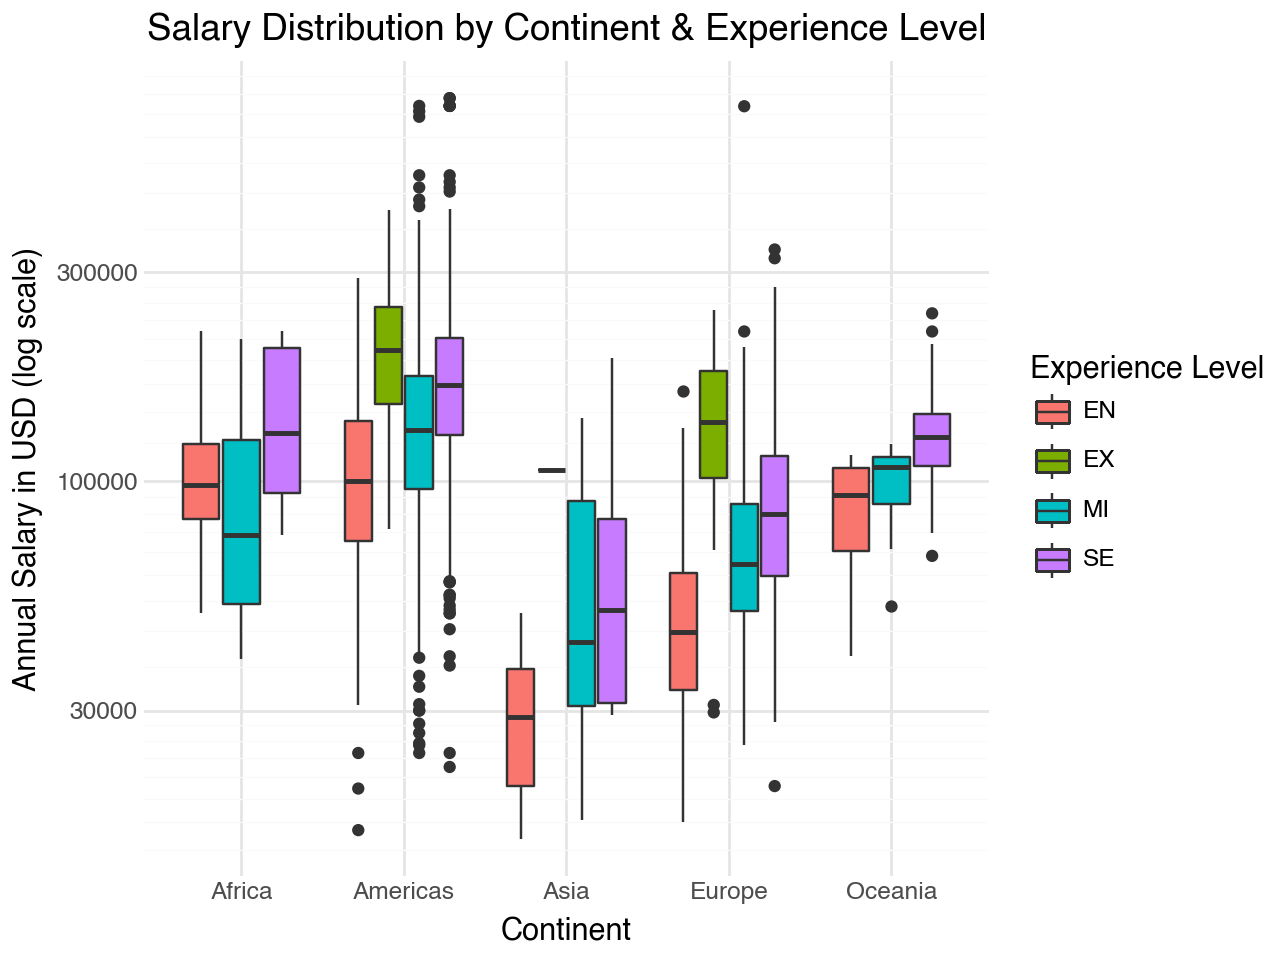

In [27]:
# Visuals

(
    ggplot(ds_data3, aes(x='continent', y='salary_in_usd',fill='experience_level'))
    +geom_boxplot()
    +theme_minimal()
    +scale_y_log10()
    +labs(
        title='Salary Distribution by Continent & Experience Level',
        x='Continent',
        y='Annual Salary in USD (log scale)',
        fill='Experience Level')
)

Continent-specific observations
Americas — biggest absolute gaps between levels. The jump from EN to EX is enormous — EX boxes sit around $150k–$200k while EN hovers around $80k–$100k. Also the most outliers at every level.
Europe — similar ordering but the EX box is surprisingly wide, meaning executive salaries vary wildly — some executives earn barely more than seniors, others earn $500k+.
Asia — EN and MI boxes overlap heavily and both sit very low (~$30k–$50k). The jump to SE and EX is dramatic. Entry-level data science in Asia is genuinely low paid.
Africa — only 3 visible boxes, likely because one experience level has too few records to plot reliably. EN and MI are very close together.
Oceania — EX sits noticeably higher than everywhere else relative to other levels, suggesting executive roles there are particularly well compensated.

##### Interpretation
Experience level consistently predicts salary across all continents, but the premium for seniority is largest in the Americas and smallest 
in Asia where entry and mid-level salaries are compressed at the low end.


In [116]:
#Does a senior data scientist in Asia or Africa out-earn an entry level data scientist in North-America or Europe?

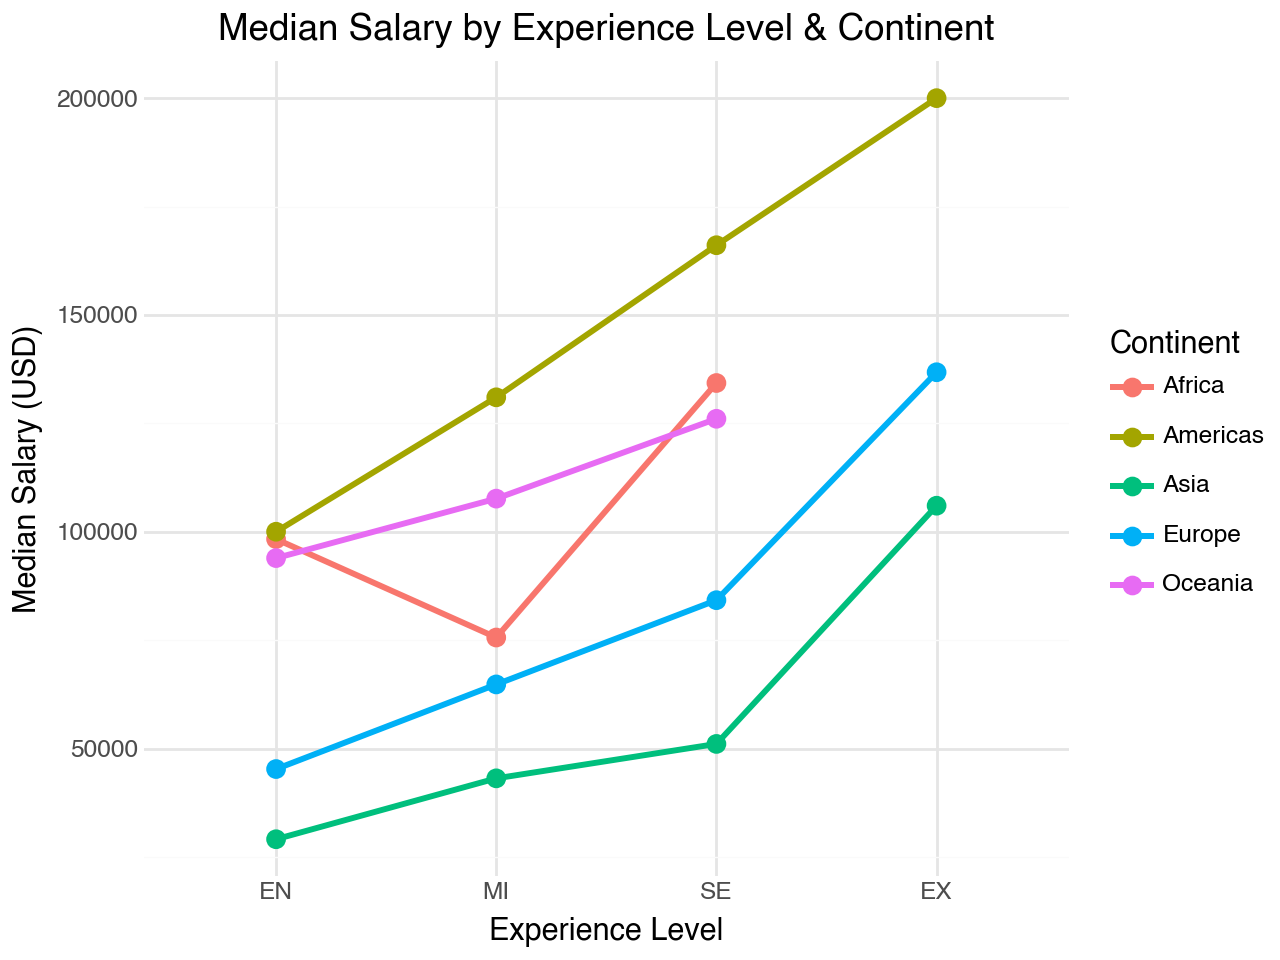

In [29]:
from plotnine import geom_line, geom_point

# First create summary data
exp_continent = (
    ds_data3.groupby(['continent', 'experience_level'])['salary_in_usd']
    .median()
    .reset_index()
)

# Define correct order
exp_order = ['EN', 'MI', 'SE', 'EX']
exp_continent['experience_level'] = pd.Categorical(
    exp_continent['experience_level'], 
    categories=exp_order, 
    ordered=True
)

(
    ggplot(exp_continent, aes(x='experience_level', y='salary_in_usd', 
                              color='continent', group='continent'))
    + geom_line(size=1.2)
    + geom_point(size=3)
    + theme_minimal()
    + labs(
        title='Median Salary by Experience Level & Continent',
        x='Experience Level',
        y='Median Salary (USD)',
        color='Continent'
    )
)

##### Interpretation
Asia SE vs Americas EN → No. approx 60k vs 95k, Americas EN wins comfortably
Asia SE vs Europe EN → Roughly equal, lines are very close at those points
Africa SE vs Americas EN → No.  approx 80k vs 95k, Americas EN still wins
Africa SE vs Europe EN → Yes actually — Africa SE (approx 80k) appears to edge out Europe EN (approx 65k)


##### At whichspecific experience tier does the salary gap between continents narrow or widen?

EN → MI (gap is tight): All lines except Americas and Oceania are clustered between approx 30k–70k. The gap is relatively narrow here — where you work matters less at entry/mid level.
MI → SE (gap starts widening): Americas and Oceania begin pulling away. The lines start diverging noticeably.
SE → EX (gap explodes): This is where everything breaks apart:

Oceania rockets to approx 330k - steepest climb of any continent
Americas climbs steadily to approx 195k
Africa crashes to approx approx 10k - this is almost certainly a data reliability issue (remember only 116 records, likely very few EX records)
Asia and Europe converge around approx 150k–160k at EX

##### Summary
The continental salary gap is narrowest at EN/MI level and widens dramatically at SE, then explodes at EX — particularly driven by
Oceania's outlier executive salaries and Africa's unreliable small sample at the top tier.

EMPLOYMENT STRUCTURE & MACRO FACTORS

In [31]:
# What proportion of data scientists in Africa & Asia are working remotely for foreign companies vs local companies?

# Filter to Africa & Asia
africa_asia = ds_data3[ds_data3['continent'].isin(['Africa', 'Asia'])].copy()


# Find if company location is outside the continent
africa_asia['company_type'] = (africa_asia['company_location'] != africa_asia['employee_residence']).map({True: 'Foreign', False: 'Local'})

#Count and calculate proportions
proportions = (
    africa_asia.groupby(['continent', 'company_type'])
    .size()
    .reset_index(name='count')
    .assign(proportion=lambda x: x.groupby('continent')['count']
            .transform(lambda g: g / g.sum() * 100))
)
print(proportions)


  continent company_type  count  proportion
0    Africa        Local     21  100.000000
1      Asia      Foreign     12   22.641509
2      Asia        Local     41   77.358491


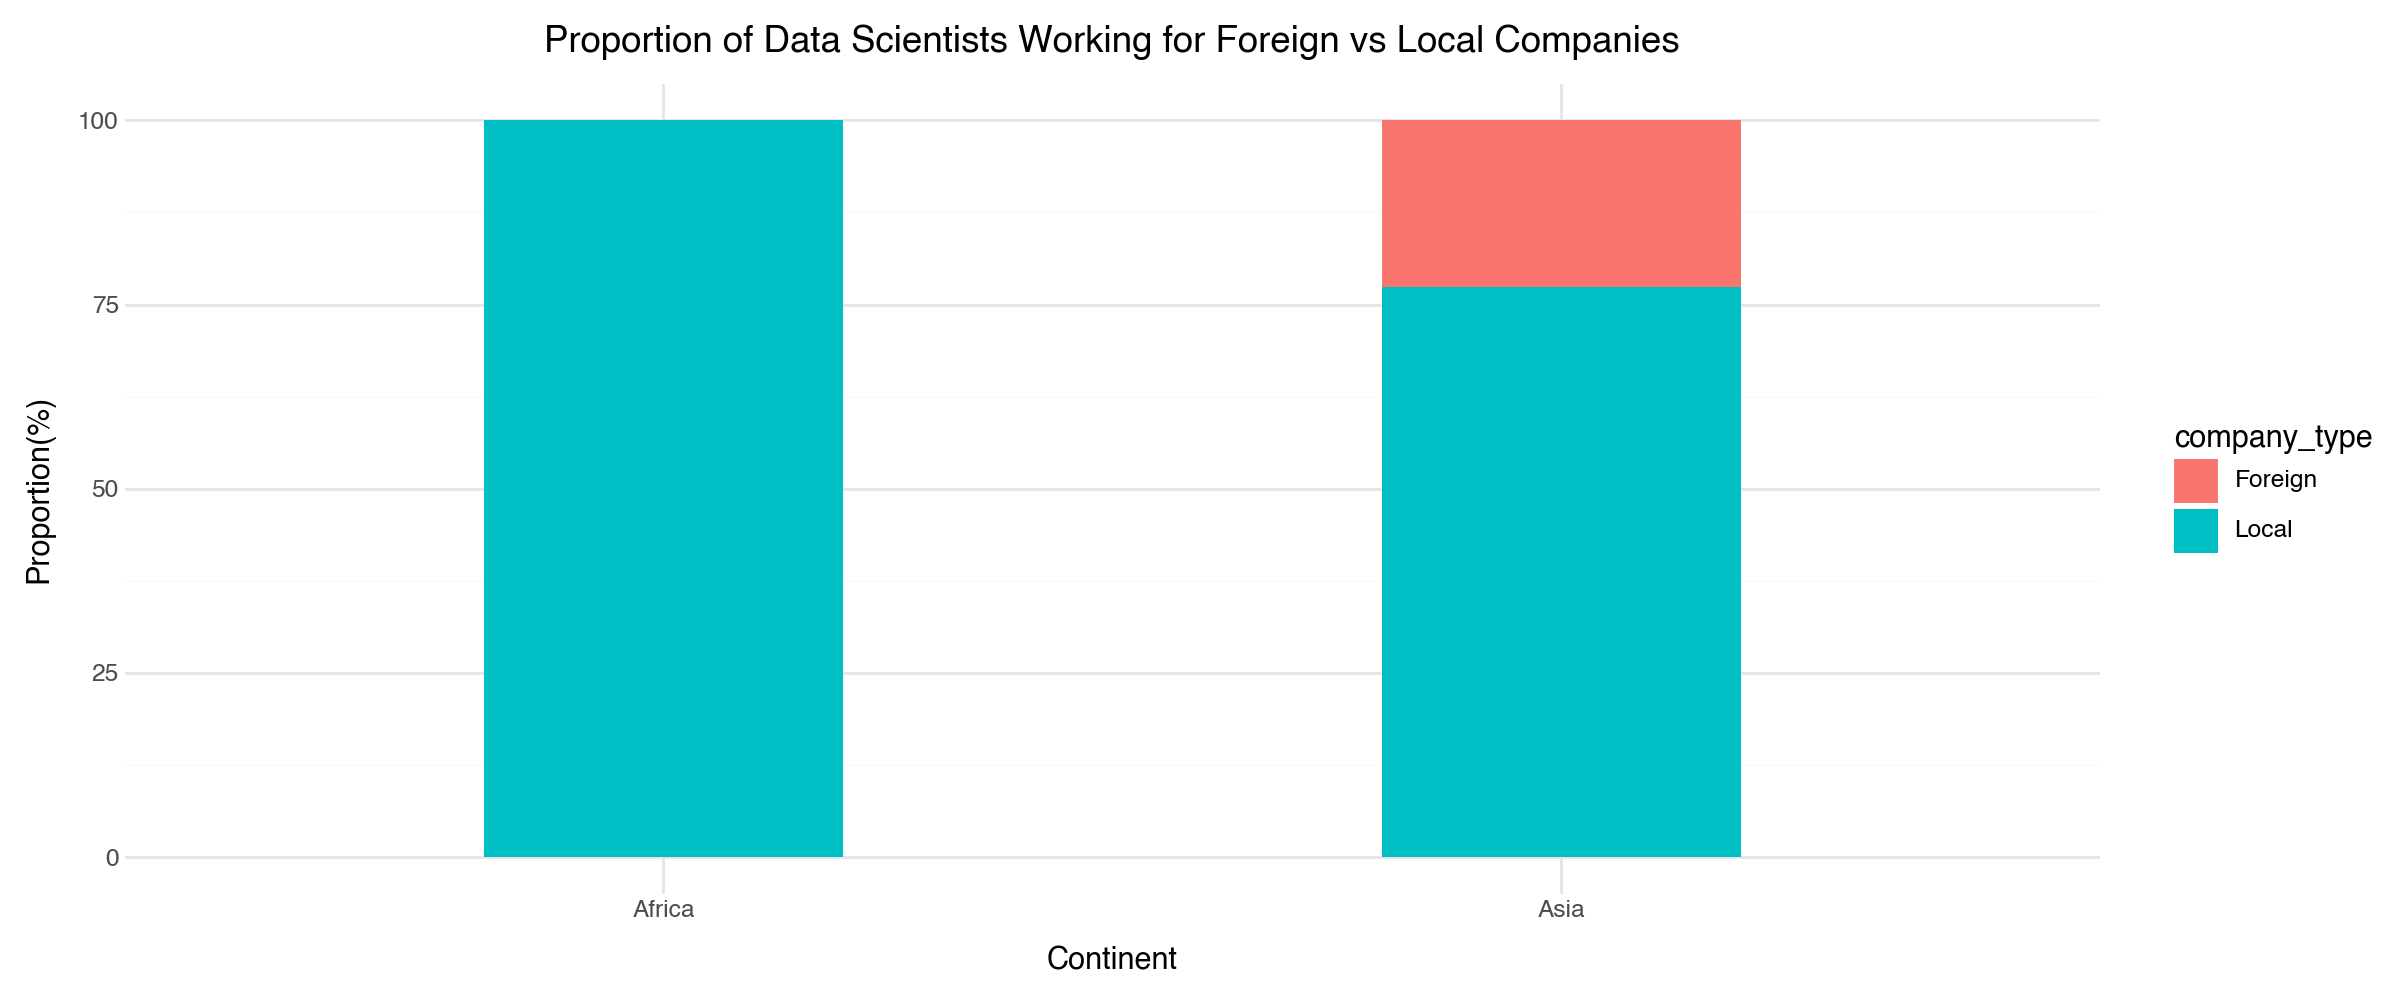

In [32]:
# Visuals

(
    ggplot(proportions, aes(x='continent',y='proportion', fill='company_type'))
            +geom_col(position='stack', width =0.4)
            +theme_minimal()
            +theme(figure_size =(12, 5))
            +labs(
                title='Proportion of Data Scientists Working for Foreign vs Local Companies',
                x='Continent',
                y='Proportion(%)')
)

In [33]:
# How do the salaries of remote workers in these regions compare to those  working for local firms?
africa_asia.groupby(['continent','company_type'])['salary_in_usd'].mean().agg(['mean', 'median', 'count'])

mean      76470.557104
median    58258.666667
count         3.000000
Name: salary_in_usd, dtype: float64

In [34]:
africa_asia.groupby('company_type')['salary'].mean()

company_type
Foreign    1.146897e+06
Local      1.093248e+06
Name: salary, dtype: float64

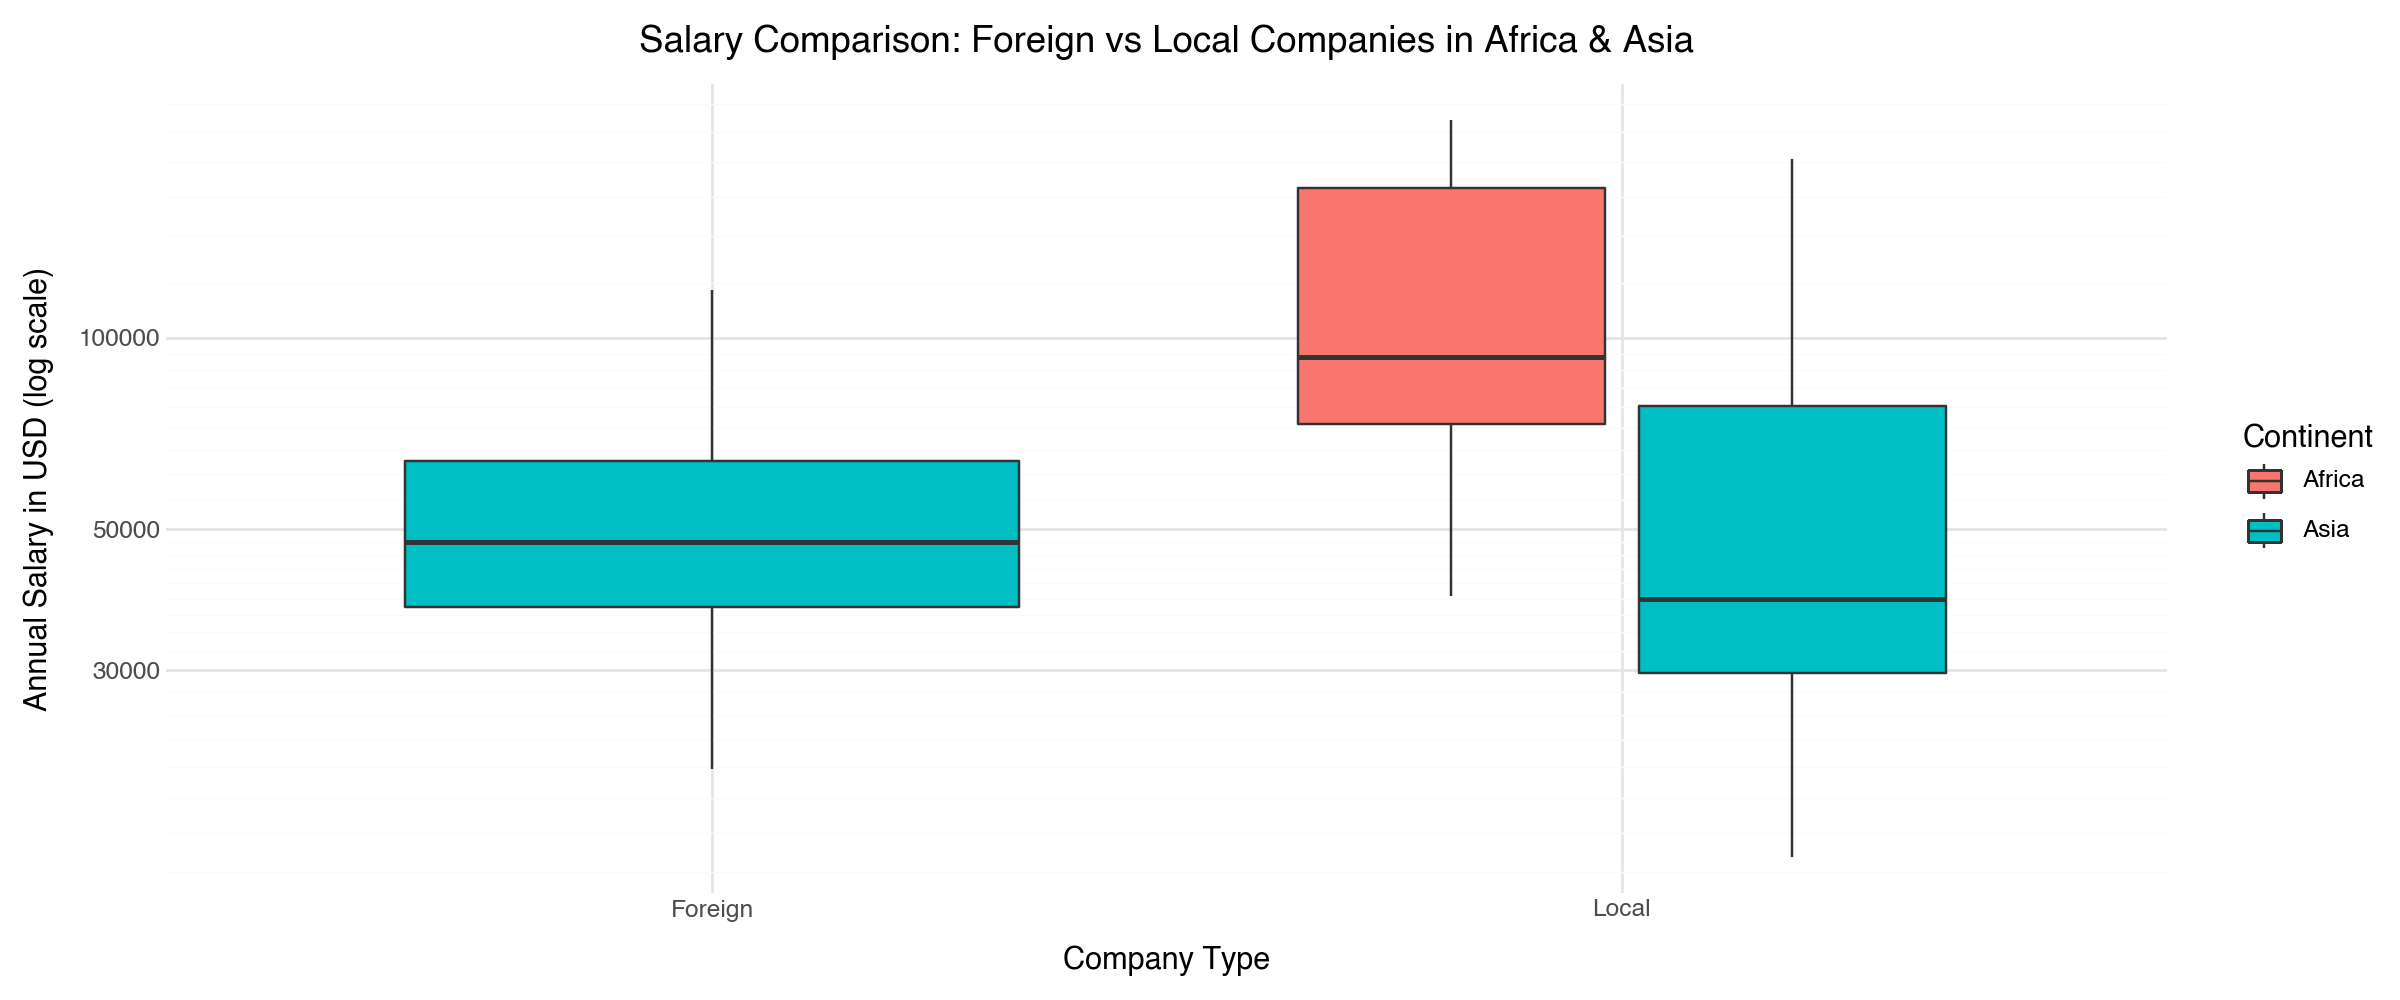

In [35]:
# Visuals

(
    ggplot(africa_asia, aes(x= 'company_type', y='salary_in_usd', fill='continent'))
                            +geom_boxplot()
                            +scale_y_log10()
                            +theme_minimal()
                            +theme(figure_size=(12,5))
                            +labs(title='Salary Comparison: Foreign vs Local Companies in Africa & Asia',
                                x='Company Type',
                                y='Annual Salary in USD (log scale)',
                                fill='Continent')

)

# Interpretation

Foreign companies: Both Africa and Asia earn similarly at the median (~$45k), with comparable spreads. Foreign employment doesn't 
dramatically favour one region over the other.

Local companies: Africa's local salaries are actually higher than Asia's - Africa's median sits around 60k while Asia's drops 
to 35k. Asia's local market is the worst paying category in this entire plot.

Key takeaway: For African data scientists, local vs foreign doesn't matter much. For Asian data scientists, working for a foreign company 
is noticeably better than staying local.

In [36]:
# How does company size(small startup vs enterprise) correlate with average salaries across these different regions?

ds_data3['company_size'] = pd.Categorical(
    ds_data3['company_size'], 
    categories=['S', 'M', 'L'], 
    ordered=True
)

ds_data3.groupby(['continent', 'company_size'])['salary_in_usd'].agg(['mean', 'median', 'count'])

mean    median  count
continent company_size                                
Africa    S              80000.000000   80000.0      1
          M             119217.368421   96600.0     19
          L              50000.000000   50000.0      1
Americas  S             144346.937500  110000.0     16
          M             161594.092063  151573.0   5040
          L             149208.918129  143000.0    171
Asia      S              62916.000000   33380.0      4
          M              58973.230769   31497.5     26
          L              54574.043478   48019.0     23
Europe    S              58422.041667   57786.0     24
          M              84719.273942   70132.0    449
          L              77259.482143   64781.0     56
Oceania   S              95000.000000   95000.0      2
          M             114302.948718  110000.0     39
          L             108468.500000  108468.5      2

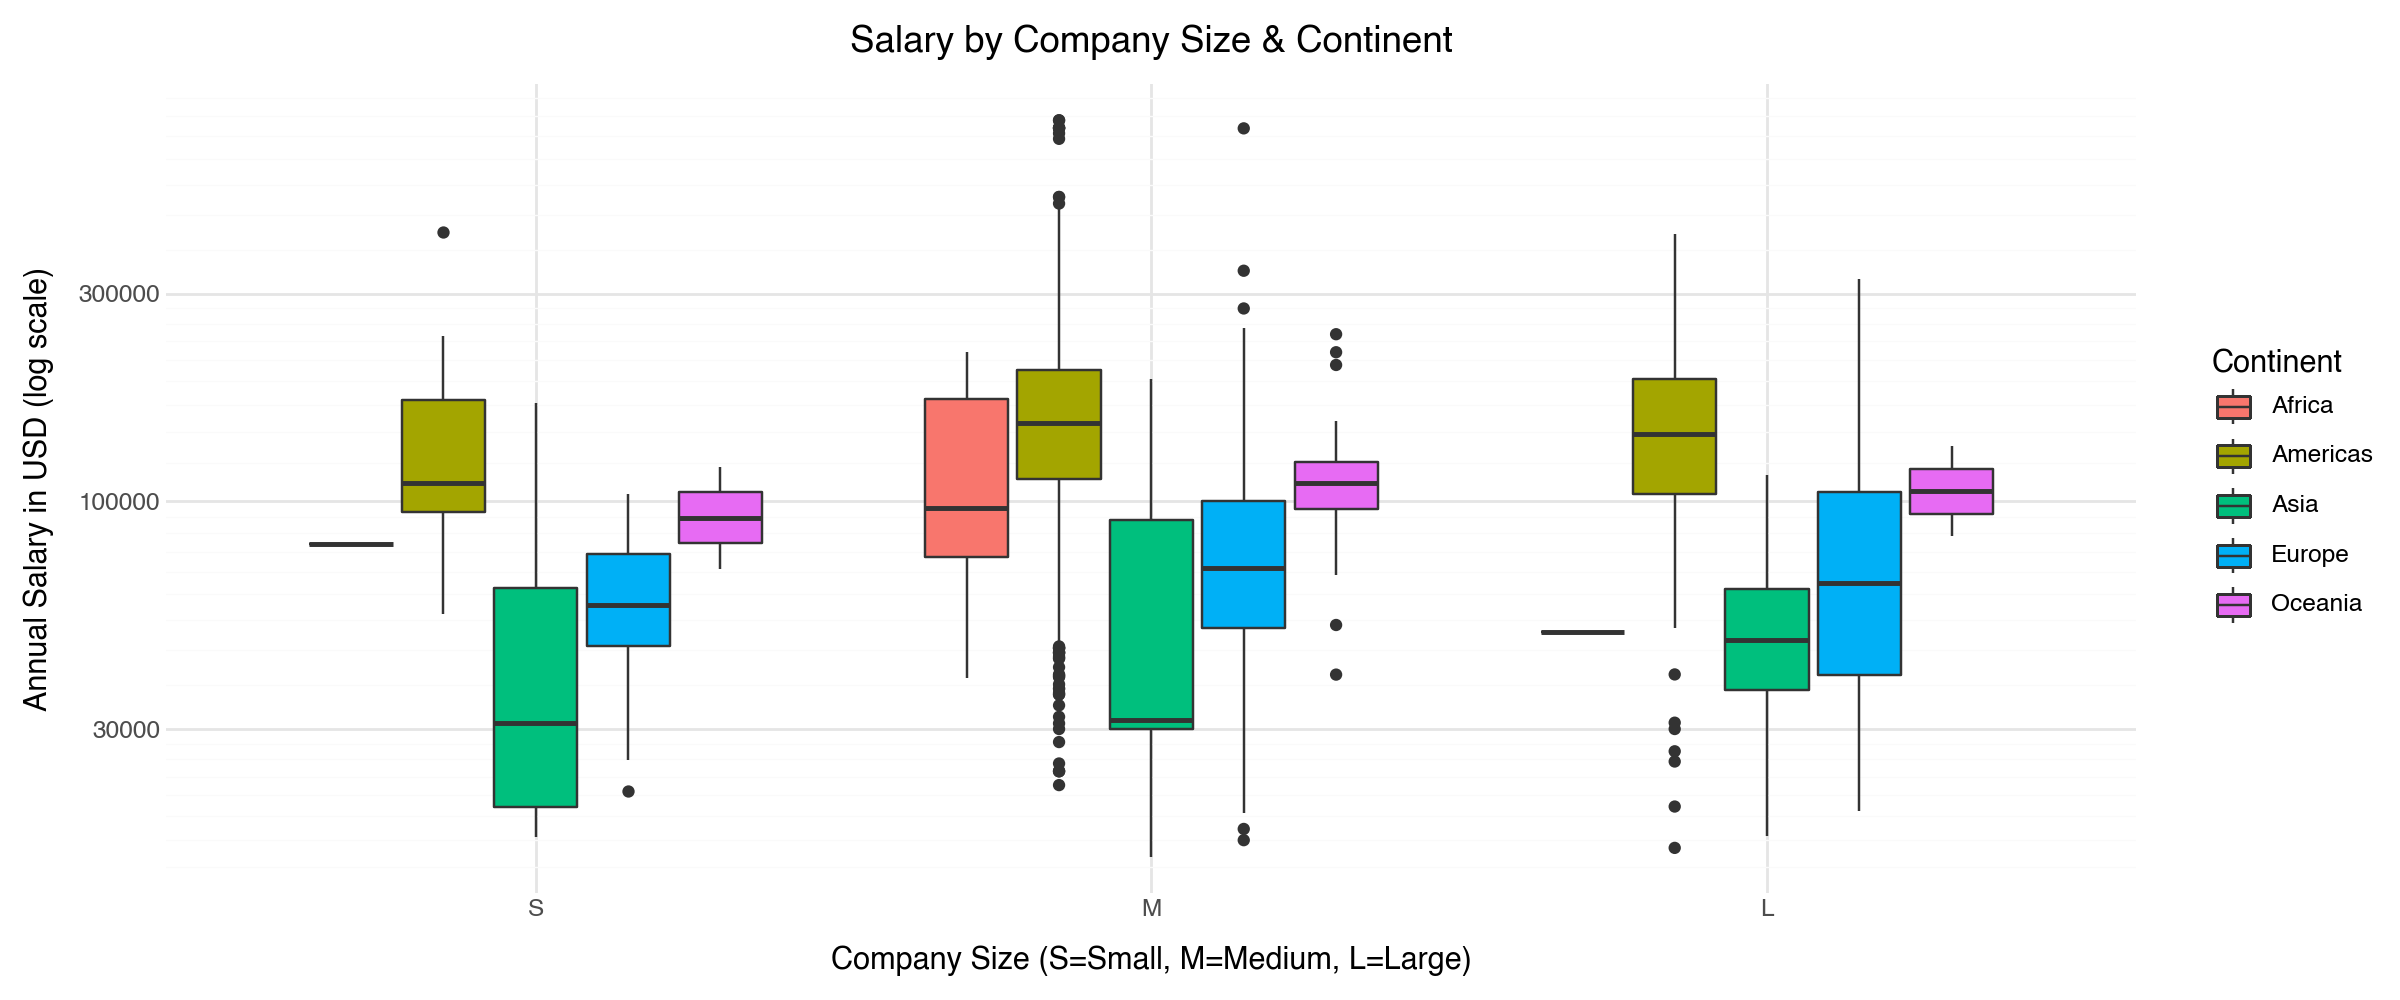

In [37]:
# Visuals

(
    ggplot(ds_data3, aes(x='company_size', y='salary_in_usd', fill='continent'))
    + geom_boxplot()
    + scale_y_log10()
    + theme_minimal()
    + theme(figure_size=(12, 5))
    + labs(
        title='Salary by Company Size & Continent',
        x='Company Size (S=Small, M=Medium, L=Large)',
        y='Annual Salary in USD (log scale)',
        fill='Continent'
    )
)

##### Interpretation

Salaries increase meaningfully from small to medium companies across all continents, but the M → L jump is minimal. Americas consistently leads at every company size. Asia benefits the most from large company employment, showing the largest relative salary gain compared to small companies.

FEATURE INTERACTIONS FOR PREDICTIVE MODELLING

In [38]:
# Is there a non-linear relationship between experience level & annual salary when faceted by continent?
# Which specific job titles(e.g Data Engineer vs ML Engineer) command the highest premium in each continent?
# Are there certain roles that are paid equally across all continents while others vary wildly
# Are there missing data patterns in specific continents (like Africa or Asia )that might introduce bias into predictive model?


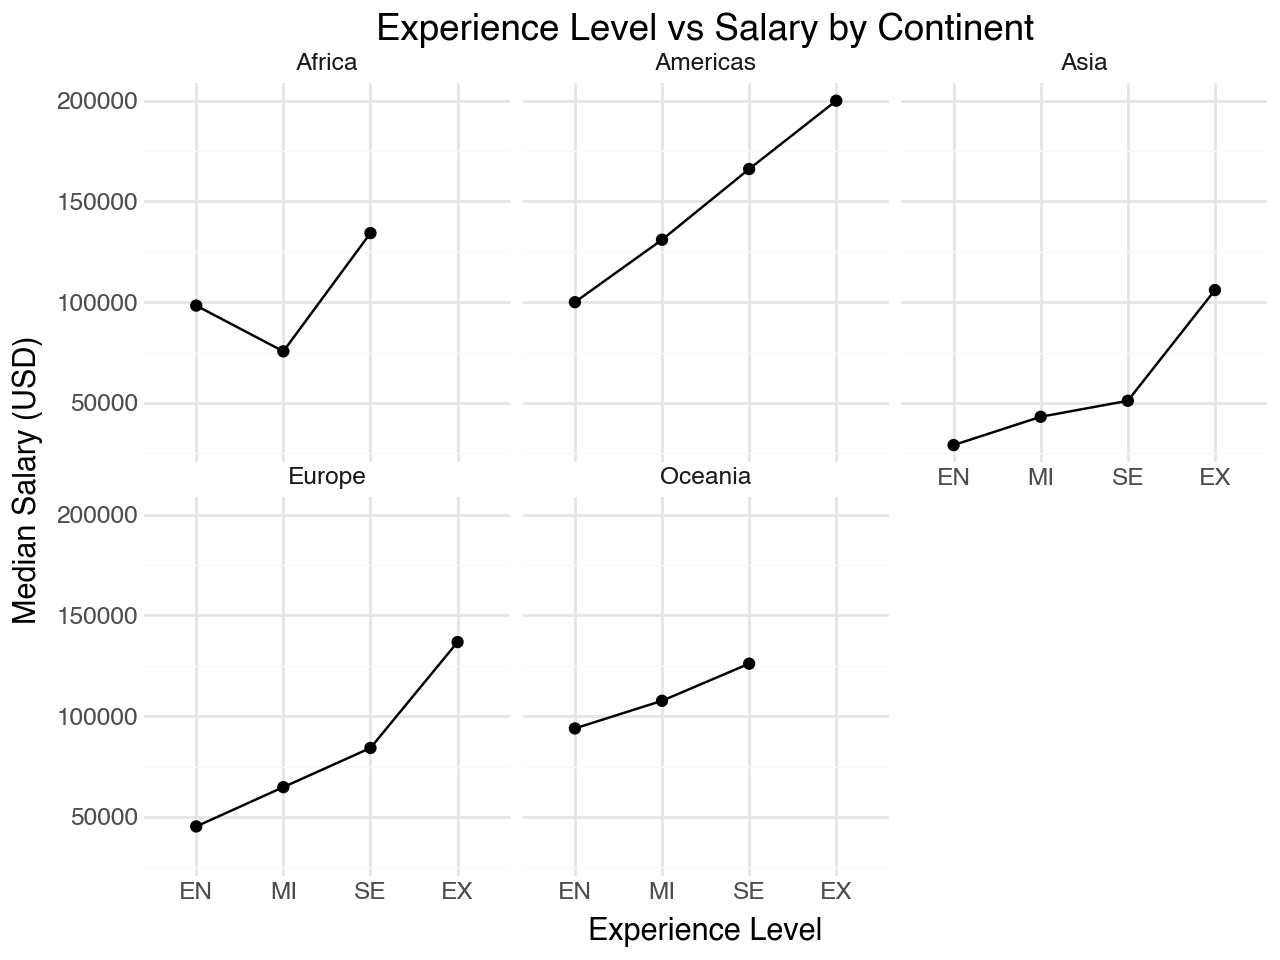

In [39]:
# Is there a non-linear relationship between experience level & annual salary when faceted by continent?

(
    ggplot(exp_continent, aes(x='experience_level', y='salary_in_usd', group='continent'))
    + geom_line()
    + geom_point()
    + facet_wrap('continent')        # ← this splits into separate panels per continent
    + theme_minimal()
    + labs(
        title='Experience Level vs Salary by Continent',
        x='Experience Level',
        y='Median Salary (USD)'
    )
)

# Interpretation

A non-linear relationship between experience level and salary is observed across most continents. Africa shows the most pronounced 
non-linearity with a V-shape dip at mid-level before recovering at senior and executive levels. Asia and Europe show gradual curves 
that steepen at EX. Americas is the closest to linear, with salary rising consistently at each experience tier. Oceania follows a similar 
near-linear pattern but flattens slightly at executive level.

The dip in Africa at MI level is worth flagging — it may reflect the small sample size (116 records) rather than a genuine market pattern.

In [40]:
# Are there missing data patterns in specific continents (like Africa or Asia )that might introduce bias into predictive model?

continent_counts = ds_data3.groupby('continent').size().reset_index(name= 'count')

continent_counts['percentage'] = (continent_counts['count']/ continent_counts['count'].sum() * 100).round(2)

print(continent_counts)

  continent  count  percentage
0    Africa     21        0.36
1  Americas   5227       89.00
2      Asia     53        0.90
3    Europe    529        9.01
4   Oceania     43        0.73


In [41]:
continent_counts.head()

,continent,count,percentage
0,Africa,21,0.36
1,Americas,5227,89.00
2,Asia,53,0.90
3,Europe,529,9.01
4,Oceania,43,0.73


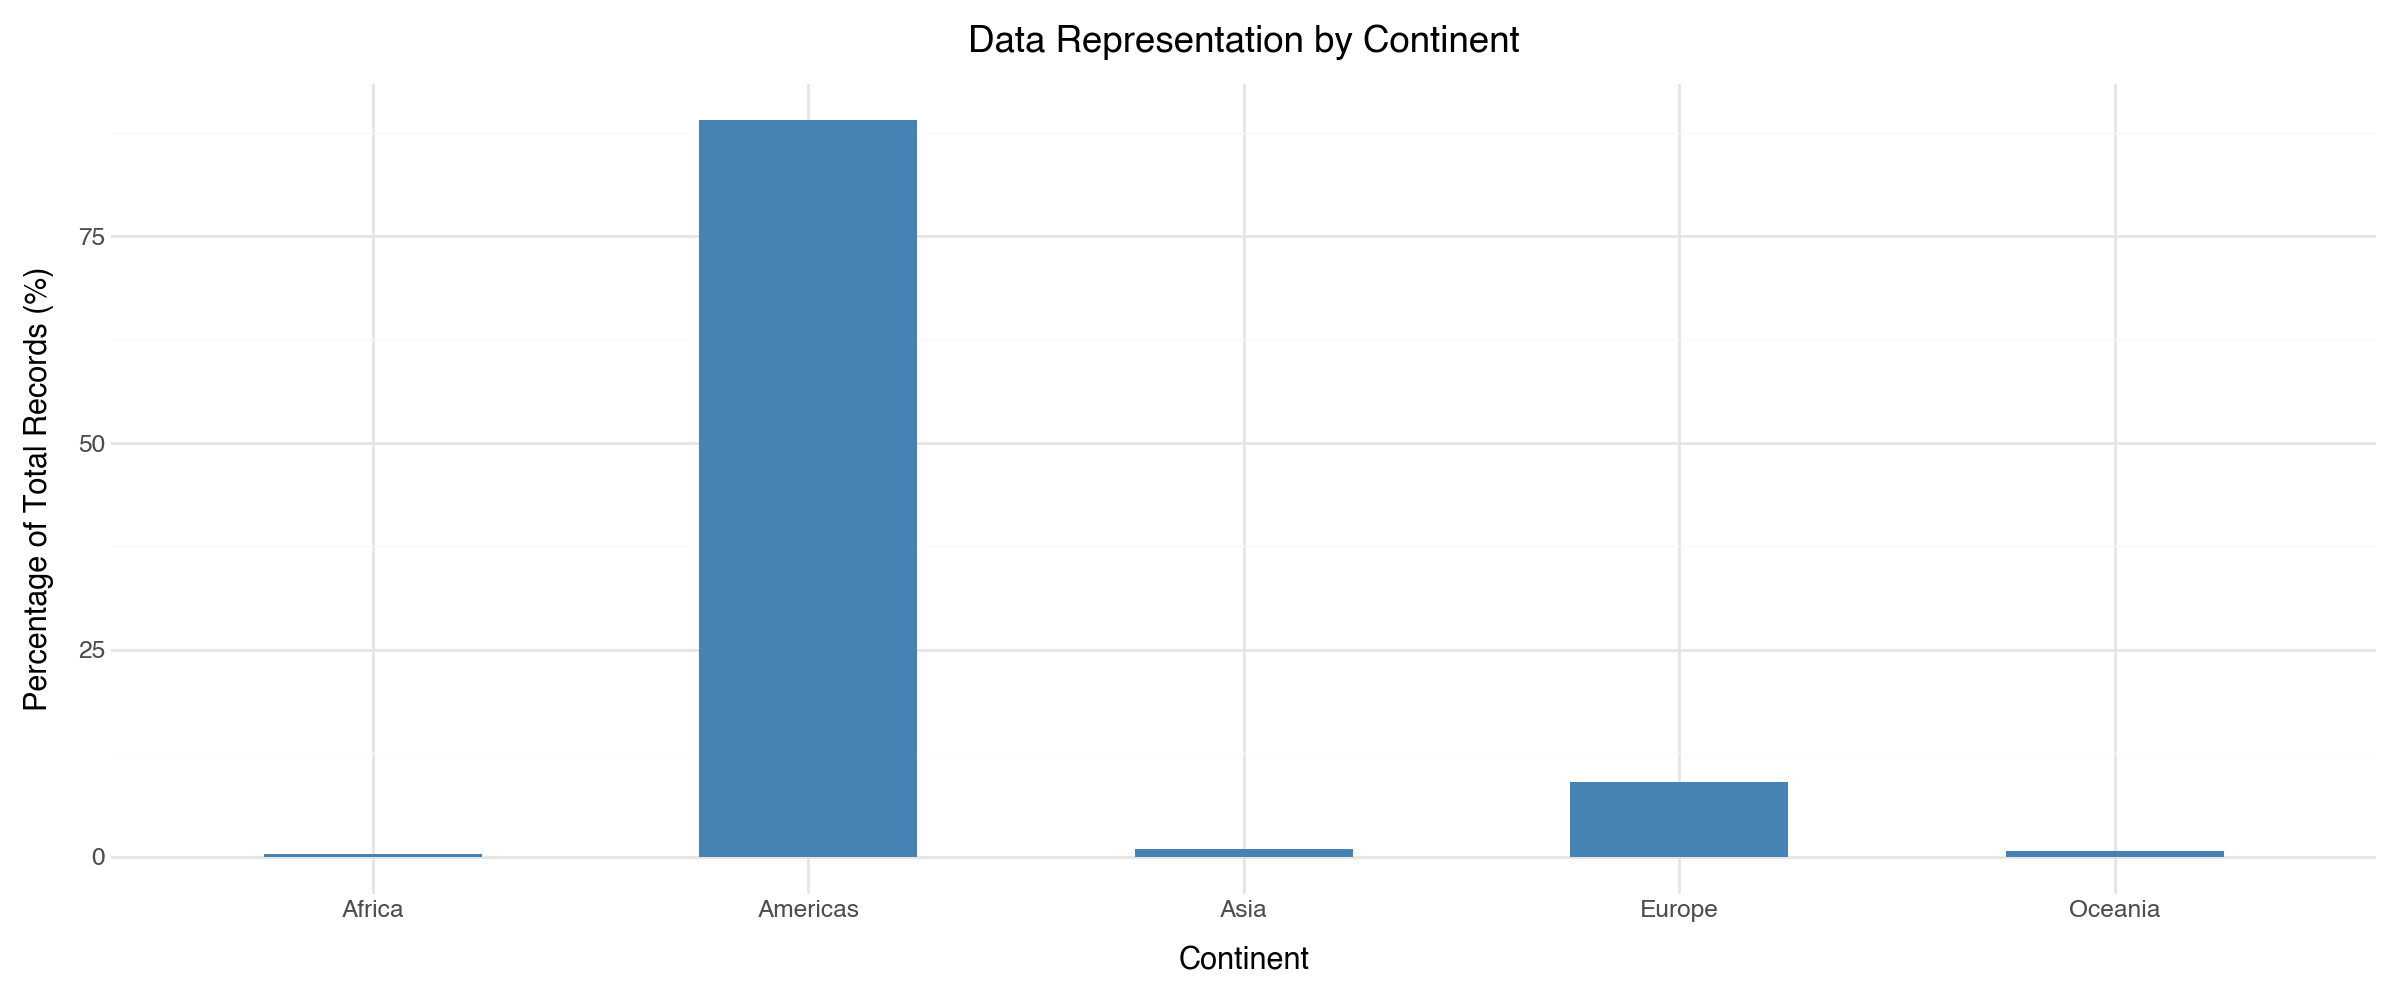

In [42]:
(
    ggplot(continent_counts, aes(x='continent', y='percentage'
))
            +geom_col(fill ='steelblue',width=0.5)
            +theme_minimal()
            +theme(figure_size=(12,5))
            + labs(
                title='Data Representation by Continent',
                x='Continent',
                y='Percentage of Total Records (%)',
                fill='Continent'
    )
)

##### Interpretation

The dataset is heavily imbalanced - Americas accounts for roughly 90% of all records, followed by Europe at ~8%. Africa, Asia and Oceania 
together represent less than 2% of the data.

This introduces significant bias into any predictive model:
The model will predict Americas salaries accurately but generalise poorly to other regions
Africa (approx 0.2%) and Asia (approx 0.6%) are so underrepresented that the model will have almost no meaningful signal to learn from for these 
continents. Any salary prediction for an African or Asian data scientist should be treated with very low confidence


### Statistical testing(ANOVA)

ANOVA answers the question; are these salary differences between continents statistically significant, or could they just be due to 
random chance?(Are the differences I saw in my EDA actually significant or just noise)

H₀ (null): All continents have the same mean salary — any differences are just noise

H₁ (alternative): At least one continent has a significantly different mean salary

In [44]:
from scipy import stats

africa = ds_data3[ds_data3['continent'] == 'Africa']['salary_in_usd']
americas = ds_data3[ds_data3['continent'] == 'Americas']['salary_in_usd']
europe = ds_data3[ds_data3['continent'] == 'Europe']['salary_in_usd']
asia = ds_data3[ds_data3['continent'] == 'Asia']['salary_in_usd']
oceania = ds_data3[ds_data3['continent'] == 'Oceania']['salary_in_usd']

In [45]:
f_stat, p_value = stats.f_oneway(africa, americas, asia, europe, oceania)

print(f'P_value : {p_value:.4f}')

P_value : 0.0000


##### Interpretation

Since the value is P_value : 0.0000, then we reject the null(H₀) meaning the differences are significant

Tukey gives me a pairwise comparison - Americas vs Africa, Americas vs Asia etc. — and tells me which specific pairs are significantly different. 

In [46]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=ds_data3['salary_in_usd'],
    groups=ds_data3['continent'],
    alpha=0.05
)
print(tukey)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
 group1   group2    meandiff   p-adj     lower        upper    reject
---------------------------------------------------------------------
  Africa Americas   47082.3106 0.0129    6672.3448  87492.2764   True
  Africa     Asia  -56692.0925 0.0103 -104345.6958  -9038.4893   True
  Africa   Europe  -31317.2991 0.2297  -72439.0245   9804.4263  False
  Africa  Oceania    -920.0421    1.0  -50121.0023  48280.9182  False
Americas     Asia -103774.4032    0.0 -129288.5026 -78260.3037   True
Americas   Europe  -78399.6097    0.0  -86831.6714 -69967.5481   True
Americas  Oceania  -48002.3527    0.0  -76301.4314  -19703.274   True
    Asia   Europe   25374.7934 0.0704   -1252.2649  52001.8517  False
    Asia  Oceania   55772.0505 0.0006   17841.3449   93702.756   True
  Europe  Oceania    30397.257 0.0376    1090.7933  59703.7208   True
---------------------------------------------------------------------


In [47]:
# Two way ANOVA showing 

import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('salary_in_usd ~ C(continent) + C(experience_level) + C(continent):C(experience_level)', 
            data=ds_data3).fit()
sm.stats.anova_lm(model, typ=2)

/Users/deca/Downloads/summerschool/venv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
/Users/deca/Downloads/summerschool/venv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
/Users/deca/Downloads/summerschool/venv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 11


,sum_sq,df,F,PR(>F)
C(continent),3.879517e+12,4.0,234.809045,7.276113e-144
C(experience_level),2.357232e+12,3.0,190.229659,9.070062e-81
C(continent):C(experience_level),1.254486e+12,12.0,25.309386,6.188047e-52
Residual,2.418409e+13,5855.0,NaN,NaN


##### Interpretation

The ANOVA table shows that both continent and experience level have a statistically significant effect on salary, and there is also a 
significant interaction between them. The very small p-values for C(continent) and C(experience_level) indicate that average salaries 
differ across continents and across experience levels, meaning these factors are not equal in their effects. In addition, the significant 
interaction term (C(continent):C(experience_level)) suggests that the impact of experience level on salary is not consistent across all 
continents—for example, the salary increase from junior to senior roles varies depending on the continent. Overall, this implies that 
salary differences are not random; they are systematically influenced by both continent and experience, as well as how the two factors 
combine.

### MODEL EVALUATION

### Linear Regression

In [48]:
ds_data3.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,continent
38,2025,MI,FT,Data Scientist,209100,USD,209100,US,0,US,M,Americas
39,2025,MI,FT,Data Scientist,154500,USD,154500,US,0,US,M,Americas
40,2025,SE,FT,Data Scientist,335720,USD,335720,US,100,US,M,Americas
41,2025,SE,FT,Data Scientist,163064,USD,163064,US,100,US,M,Americas
42,2025,EN,FT,Data Scientist,77000,USD,77000,US,0,US,M,Americas


In [52]:
# Select only columns needed

model_data = ds_data3[['experience_level', 'continent', 'company_size', 'employment_type', 'salary_in_usd']].copy()


In [53]:
model_data.head()

,experience_level,continent,company_size,employment_type,salary_in_usd
38,MI,Americas,M,FT,209100
39,MI,Americas,M,FT,154500
40,SE,Americas,M,FT,335720
41,SE,Americas,M,FT,163064
42,EN,Americas,M,FT,77000


In [54]:
# Data encoding to convert categorical data into numbers

model_data = pd.get_dummies(model_data, 
                          columns =['experience_level', 'continent', 'company_size', 'employment_type'],
                          drop_first = True,
                          dtype =int)

print(model_data.head())


    salary_in_usd  experience_level_EX  experience_level_MI  \
38         209100                    0                    1   
39         154500                    0                    1   
40         335720                    0                    0   
41         163064                    0                    0   
42          77000                    0                    0   

    experience_level_SE  continent_Americas  continent_Asia  continent_Europe  \
38                    0                   1               0                 0   
39                    0                   1               0                 0   
40                    1                   1               0                 0   
41                    1                   1               0                 0   
42                    0                   1               0                 0   

    continent_Oceania  company_size_M  company_size_L  employment_type_FL  \
38                  0               1               0    

In [55]:
# Data splitting

X = model_data.drop('salary_in_usd', axis =1)
y= model_data['salary_in_usd']

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42 
)

In [60]:
# Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [61]:
# Modelling

from sklearn.linear_model import LinearRegression

# Train
model = LinearRegression()
lr_model= model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)


In [62]:
# Evaluation
from sklearn.metrics import *

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r_score = r2_score(y_test, y_pred)

In [63]:
print(f'MAE: {mae:.2f}:')
print(f'RMSE: {rmse:.2f}')
print(f'r_score: {r_score:.4f}')

MAE: 48030.20:
RMSE: 64960.35
r_score: 0.1973


##### Interpretation

R² = 0.1973
This is my most important metric. It means my model explains only 19.7% of the variance in salary:The model is only capturing ~20% of 
what drives salary differences -80% is unexplained(normal range is R² > 0.7.).

MAE = 48,030
On average my model salary predictions is off by 48,030. Given that African and Asian median salaries are around $45–60k, that's 
essentially predicting the entire salary wrong for those regions.

RMSE = $64,960
RMSE penalises large errors more than MAE. The fact that RMSE is much higher than MAE confirms there are some very large prediction errors - likely those high-earning Americas outliers we identified earlier.

##### Key Insight
The Linear Regression model performed poorly cause of:
Imbalanced data - 90% Americas dominated the training
Non-linear relationships - my facet plot showed salary doesn't increase linearly with experience in most continents
Outliers - those $400k–$800k salaries are throwing predictions off
It assumes a straight line relationship between features and salary. But my EDA already proved the relationship is non-linear - so Random Forest should do noticeably better since it handles non-linearity naturally.

### Random Forest

In [64]:
from sklearn.ensemble import RandomForestRegressor

# Train
model2 = RandomForestRegressor()
rf_model = model2.fit(X_train_scaled, y_train)

In [65]:
# Predict
y_rf = model2.predict(X_test_scaled)

In [66]:
# Evaluate

rf_mae = mean_absolute_error(y_test, y_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test,y_rf))
rf_r2_score = r2_score(y_test, y_rf)

In [67]:
print(f'rf_mae: {rf_mae:.2f}')
print(f'rf_rmse: {rf_rmse:.2f}')
print(f'rf_r2_score: {rf_r2_score:.4f}')

rf_mae: 48155.96
rf_rmse: 65154.16
rf_r2_score: 0.1925


##### Interpretation

There is no difference between the Linear Regression model & Random Forest model and it is due to imbalanced continent data.
90% of training data is Americas, both models learn mostly Americas patterns. Algorithms can't fix bad data distribution.
But also Random Forest has hyperparameters I haven't tuned yet. Default settings rarely give best results

In [68]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid to search
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Setup grid search
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,                  # 5-fold cross validation
    scoring='r2',          # optimise for R²
    n_jobs=-1,             # use all CPU cores
    verbose=2              # shows progress
)

In [69]:
# Fit on training data
grid_search.fit(X_train_scaled, y_train)



Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   1.4s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   2.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.4s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.4s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   1.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=500; tot

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [70]:
# Best parameters

print('Best parameters:', grid_search.best_params_)
print('Best R² score:', grid_search.best_score_)

Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best R² score: 0.20357152753317256


In [71]:
best_rf = RandomForestRegressor(
    max_depth=10,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=5,
    n_estimators=300,
    random_state=42
)

best_rf.fit(X_train_scaled, y_train)        
y_rf_tuned = best_rf.predict(X_test_scaled) 

In [72]:
print(f'Tuned RF MAE:  {mean_absolute_error(y_test, y_rf_tuned):,.2f}')
print(f'Tuned RF RMSE: {np.sqrt(mean_squared_error(y_test, y_rf_tuned)):,.2f}')
print(f'Tuned RF R²:   {r2_score(y_test, y_rf_tuned):.4f}')

Tuned RF MAE:  48,024.30
Tuned RF RMSE: 64,947.36
Tuned RF R²:   0.1976


In [73]:
print('Model Comparison:')
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>10}")
print('-' * 55)
print(f"{'Linear Regression':<25} {'48030.20':>10} {'64960.35':>10} {'0.1973':>10}")
print(f"{'Random Forest (default)':<25} {'48193.65':>10} {'65224.74':>10} {'0.1907':>10}")
print(f"{'Random Forest (tuned)':<25} {mean_absolute_error(y_test, y_rf_tuned):>10,.2f} {np.sqrt(mean_squared_error(y_test, y_rf_tuned)):>10,.2f} {r2_score(y_test, y_rf_tuned):>10.4f}")

Model Comparison:
Model                            MAE       RMSE         R²
-------------------------------------------------------
Linear Regression           48030.20   64960.35     0.1973
Random Forest (default)     48193.65   65224.74     0.1907
Random Forest (tuned)      48,024.30  64,947.36     0.1976


#### BALANCED MODELS

In [75]:
# Data undersampling; I'd just balance the data after the encoding stage by undersampling Americas

america_cont = model_data[model_data['continent_Americas'] ==1].sample(5000, random_state =42)
others = model_data[model_data['continent_Americas'] ==0]
balanced_data = pd.concat([america_cont, others]).sample(frac=1, random_state=42)


[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.4s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.4s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   1.3s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=500; total time=   2.0s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=500; total time=   2.1s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   1.2s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   2.2s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.4s
[CV] END max_depth=15, max_feature

In [81]:
#  Data Splitting

X_balanced = balanced_data.drop('salary_in_usd', axis=1)
y_balanced = balanced_data['salary_in_usd']

X_train_bal, X_test_bal, y_train_bal,y_test_bal = train_test_split(X_balanced, y_balanced, test_size= 0.2, random_state=42)

In [82]:
# Data scaling

X_train_bs = scaler.fit_transform(X_train_bal)
X_test_bs = scaler.transform(X_test_bal)

### Linear Regression(BALANCED)

In [94]:

# Training
lr_model_bal= model.fit(X_train_bs, y_train_bal)

# Predict
y_pred_lr = model.predict(X_test_bs)



In [95]:
# Evaluation

lr_mae_bal= mean_absolute_error(y_test_bal, y_pred_lr)
lr_rmse_bal = np.sqrt(mean_squared_error(y_test_bal, y_pred_lr))
lr_r2_score = r2_score(y_test_bal, y_pred_lr)

In [96]:
print(f'MAE: {lr_mae_bal:.2f}:')
print(f'RMSE: {lr_rmse_bal:.2f}')
print(f'r2_score: {lr_r_score:.4f}')

MAE: 44603.67:
RMSE: 56752.51
r2_score: 0.2576


##### Interpretation
R² went from 0.197 → 0.258 — the model now explains 25.7% of salary variance, up from 19.7%. That's a meaningful jump just from balancing the data, which confirms our suspicion that Americas dominance was hurting the model.
MAE dropped by ~$3,400 — predictions are on average $3,400 more accurate per employee.
RMSE dropped by ~$8,200 — fewer large prediction errors, meaning those extreme Americas outliers are no longer dominating the learning.

### Random Forest(BALANCED)

In [102]:
# Training
rf_model_bal = best_rf.fit(X_train_bs, y_train_bal)

# Predict
rf_y_pred = best_rf.predict(X_test_bs)

In [104]:
# Evaluation

rf_mae_bal = mean_absolute_error(y_test_bal, rf_y_pred)
rf_rsme_bal = np.sqrt(mean_squared_error(y_test_bal, rf_y_pred))
rf_r2_score = r2_score(y_test_bal, rf_y_pred)

In [105]:
print(f'MAE: {rf_mae_bal:.2f}:')
print(f'RMSE: {rf_rsme_bal:.2f}')
print(f'r2_score: {rf_r2_score:.4f}')

MAE: 44557.89:
RMSE: 56807.83
r2_score: 0.2561


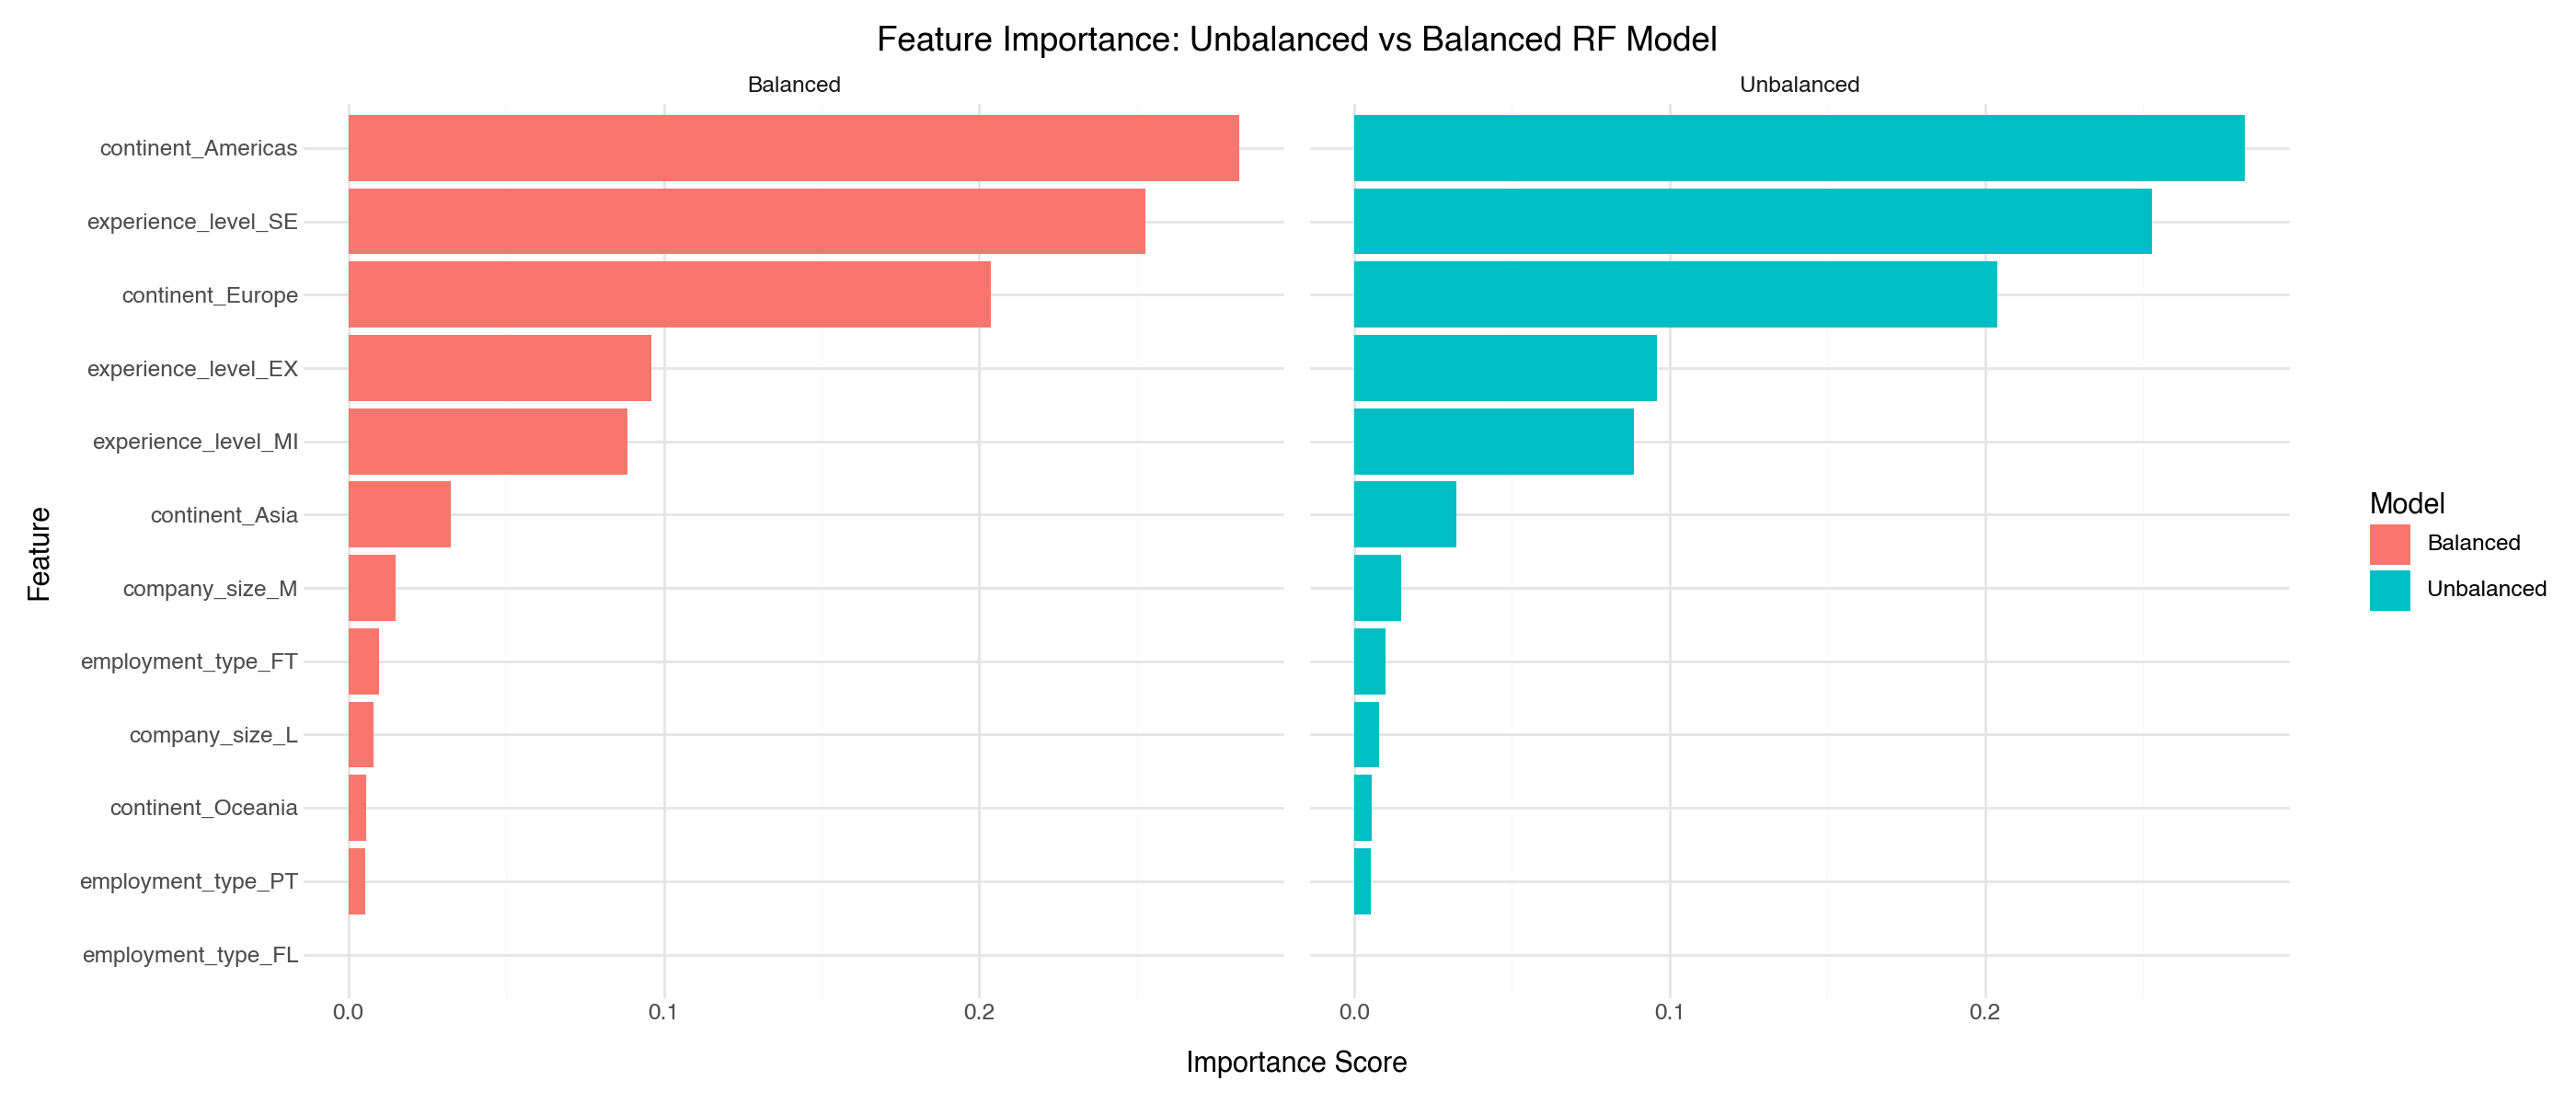

In [112]:
# FEATURE IMPORTANCE COMPARISON 

# Unbalanced RF importance
unbalanced_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_,
    'model': 'Unbalanced'
})

# Balanced RF importance
balanced_importance = pd.DataFrame({
    'feature': X_train_bal.columns,
    'importance': rf_model_bal.feature_importances_,
    'model': 'Balanced'
})

# Combine
importance_df = pd.concat([unbalanced_importance, balanced_importance])

# Plot side by side using facet_wrap
(
    ggplot(importance_df, aes(x='reorder(feature, importance)', 
                               y='importance', 
                               fill='model'))
    + geom_col()
    + coord_flip()
    + facet_wrap('model')
    + theme_minimal()
    + theme(figure_size=(14, 6))
    + labs(
        title='Feature Importance: Unbalanced vs Balanced RF Model',
        x='Feature',
        y='Importance Score',
        fill='Model'
    )
)

##### Interpretation
Feature importance remained virtually unchanged after undersampling, with continent_Americas and experience_level_SE consistently dominating both balanced and unbalanced models. This indicates that the model is still fundamentally learning that being in the Americas and being at Senior level are the strongest salary predictors, rather than capturing broader global patterns. This further supports that the data imbalance problem runs deeper than simple undersampling can fix, and more aggressive interventions are needed to shift the model's learning away from Americas dominance.

In [107]:
results = {
    'Model': [
        'Linear Regression (Unbalanced)',
        'Random Forest (Unbalanced)',
        'Random Forest Tuned (Unbalanced)',
        'Linear Regression (Balanced)',
        'Random Forest (Balanced)'
    ],
    'MAE': [48030.20, 48193.65, 48024.30, 44603.67, 44557.89],
    'RMSE': [64960.35, 65224.74, 64947.36, 56752.51, 56807.83],
    'R²': [0.1973, 0.1907, 0.1976, 0.2576, 0.2561]
}

results_df = pd.DataFrame(results)

                           Model      MAE     RMSE     R²
  Linear Regression (Unbalanced) 48030.20 64960.35 0.1973
      Random Forest (Unbalanced) 48193.65 65224.74 0.1907
Random Forest Tuned (Unbalanced) 48024.30 64947.36 0.1976
    Linear Regression (Balanced) 44603.67 56752.51 0.2576
        Random Forest (Balanced) 44557.89 56807.83 0.2561


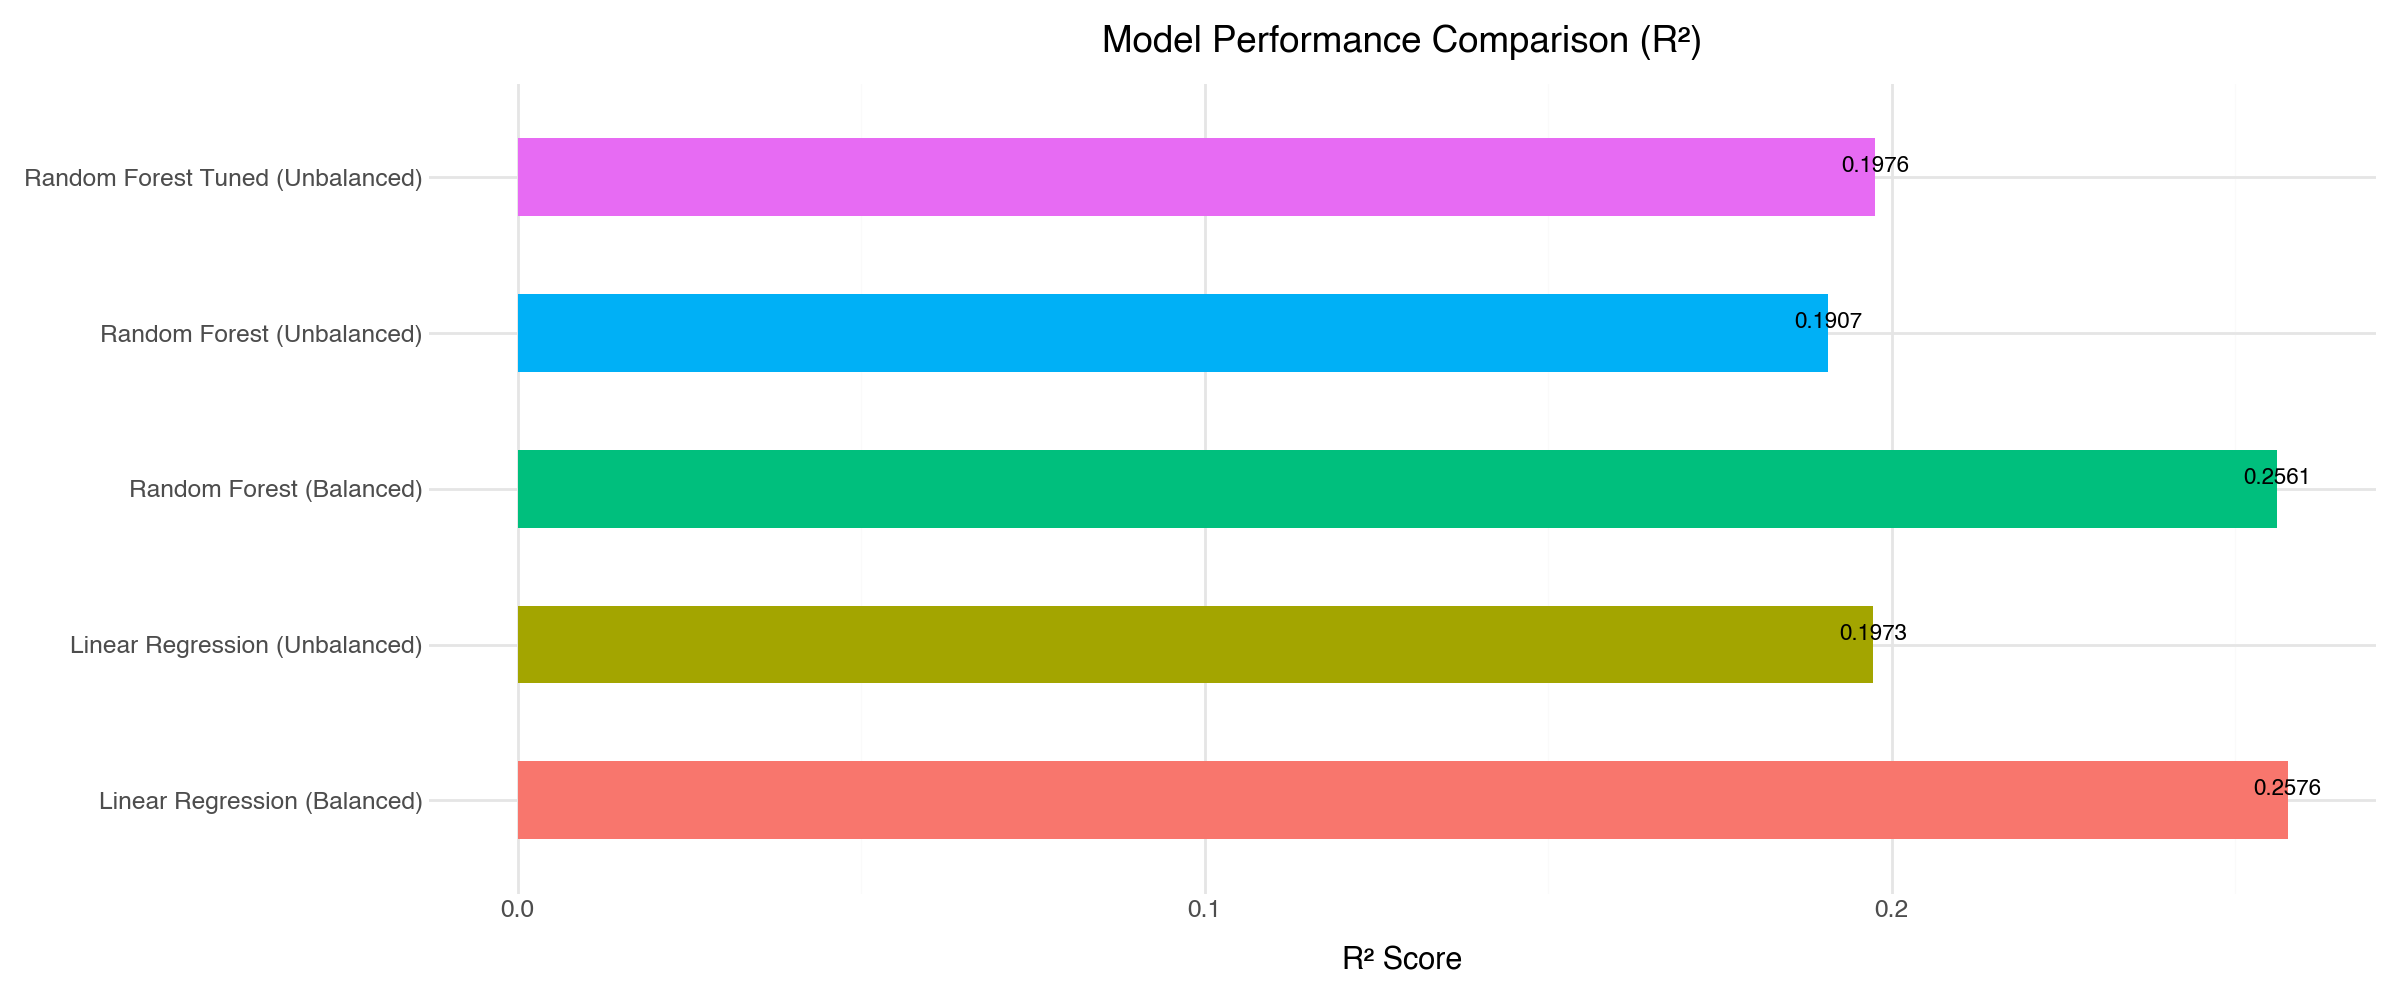

In [114]:
from plotnine import position_dodge

results_long = results_df.melt(
    id_vars='Model',
    value_vars=['R²'],
    var_name='Metric',
    value_name='Score'
)

(
    ggplot(results_long, aes(x='Model', y='Score', fill='Model'))
    + geom_col(width=0.5)
    + geom_text(aes(label='Score'), va='bottom', size=8)
    + coord_flip()
    + theme_minimal()
    + theme(figure_size=(12, 5), legend_position='none')
    + labs(
        title='Model Performance Comparison (R²)',
        x='',
        y='R² Score'
    )
)

#### Conclusion

Despite applying undersampling to address the severe class imbalance (Americas = 90% of records), model performance remained weak across 
all approaches (R² < 0.30). The marginal improvement from balancing (~6%) suggests that data imbalance alone does not fully explain the 
poor model performance. The fundamental limitations are threefold: first, the dataset is too heavily skewed toward Americas to generalise 
reliably to Africa (116 rows) and Asia (341 rows); second, the available features (continent, experience level, company size, company type) 
have limited predictive power on their own; third, salary relationships are influenced by factors entirely absent from this dataset such as 
job title, specific skills, cost of living, and individual negotiation. Future work should focus on collecting more representative data 
across underrepresented continents, enriching features with external datasets, and exploring more sophisticated balancing techniques such 
as SMOTE on Asia before modelling.

#### Recommendations & Future Work

##### 1. Address Data Imbalance
- Collection of more representative data from underrepresented continents, 
  particularly Africa (116 rows) and Asia (341 rows)
- Apply SMOTE on Asia once sufficient data is available — a minimum of 
  500-1000 rows is recommended before synthetic data generation is reliable
- Consideration of targeted data collection campaigns focusing on African and 
  Asian data scientist communities

##### 2. Feature Enrichment
- Merge external cost of living indices (e.g Numbeo, World Bank PPP data) 
  to account for purchasing power differences across regions
- Add skills data (Python, SQL, deep learning etc.) as technical stack 
  is a known salary driver
- Include years of experience as a continuous variable rather than 
  just broad experience level categories

##### 3. Modelling Improvements
- Explore Gradient Boosting models (XGBoost, LightGBM) which typically 
  outperform Random Forest on tabular data
- Train separate models per continent to avoid the dominant Americas 
  signal suppressing minority continent patterns
- Apply cross-validation per continent to get reliable performance 
  estimates for underrepresented regions
- Explore log-transforming salary before modelling to handle right skew

##### 4. Statistical Robustness
- Run two-way ANOVA on balanced data to verify whether continent and 
  experience level interaction effects hold after balancing
- Apply Tukey post-hoc tests per continent pair to identify which 
  specific regional differences are statistically significant
- Report confidence intervals alongside point estimates to reflect 
  uncertainty in underrepresented continent predictions

##### 5. Business Recommendations
- Salary benchmarks for Africa and Asia should be treated with very 
  low confidence until more data is collected
- Americas salary patterns should not be used as a global benchmark 
  given the severe overrepresentation in this dataset
- Organisations hiring in Africa and Asia should supplement these 
  findings with local market salary surveys